In [29]:
from __future__ import annotations

import sys
from datetime import datetime
from typing import Optional

import pandas as pd
from cassandra.cluster import Cluster, NoHostAvailable  # pyasyncore 설치로 Python 3.12 호환
from cassandra.policies import DCAwareRoundRobinPolicy
from cassandra.query import SimpleStatement


In [30]:
def load_from_cassandra(
    host: str = "localhost",
    port: int = 9042,
    keyspace: str = "dlim",
    table: str = "ais_class_a_dynamic",
    mmsi_list: Optional[list[str]] = None,
    start_dt: Optional[datetime] = None,
    end_dt: Optional[datetime] = None,
    limit: int = 100_000,
) -> pd.DataFrame:
    """
    Cassandra에서 AIS 데이터를 조회해 pandas DataFrame으로 반환한다.

    Parameters
    ----------
    host       : Cassandra 호스트
    port       : Cassandra 포트
    keyspace   : 키스페이스 이름
    table      : 테이블 이름
    mmsi_list  : 조회할 MMSI 목록 (None이면 전체)
    start_dt   : date_bucket 시작 시각 (포함)
    end_dt     : date_bucket 종료 시각 (포함)
    limit      : 최대 레코드 수

    Returns
    -------
    pd.DataFrame : 조회된 레코드
    """
    print(f"[Cassandra] 연결: {host}:{port} / keyspace={keyspace}")

    try:
        cluster = Cluster(
            contact_points=[host],
            port=port,
            load_balancing_policy=DCAwareRoundRobinPolicy(),
            protocol_version=4,
        )
        session = cluster.connect(keyspace)
    except NoHostAvailable as exc:
        print(f"[오류] Cassandra 연결 실패: {exc}")
        sys.exit(1)
    except Exception as exc:
        print(f"[오류] 예기치 않은 연결 오류: {exc}")
        sys.exit(1)

    COLUMNS = (
        "mmsi, date_bucket, received_at, msg_type, sog, cog, "
        "nav_status, longitude, latitude, rssi, slot_num, snr"
    )

    rows: list[dict] = []

    try:
        if mmsi_list:
            # MMSI 별로 파티션 키 범위 쿼리 → ALLOW FILTERING 불필요
            for mmsi in mmsi_list:
                cql, params = _build_single_mmsi_query(
                    table, COLUMNS, mmsi, start_dt, end_dt, limit
                )
                stmt = SimpleStatement(cql, fetch_size=1000)
                result = session.execute(stmt, params)
                rows.extend(_rows_to_dicts(result))
                if len(rows) >= limit:
                    rows = rows[:limit]
                    break
        else:
            # 전체 조회: date_bucket 범위만 적용 → ALLOW FILTERING 불가피
            cql, params = _build_full_scan_query(
                table, COLUMNS, start_dt, end_dt, limit
            )
            stmt = SimpleStatement(cql, fetch_size=1000)
            result = session.execute(stmt, params)
            rows = _rows_to_dicts(result)
    finally:
        cluster.shutdown()

    if not rows:
        print("[조회] 결과 없음 — 빈 DataFrame 반환")
        return pd.DataFrame(columns=COLUMNS.replace(" ", "").split(","))

    df = pd.DataFrame(rows)

    # datetime 변환 (Cassandra driver는 대부분 datetime으로 반환하나 명시적 보장)
    for col in ("date_bucket", "received_at"):
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], utc=True, errors="coerce")

    print(f"[조회] {table} → {len(df):,}건 로드 완료")
    return df


def _build_single_mmsi_query(
    table: str,
    columns: str,
    mmsi: str,
    start_dt: Optional[datetime],
    end_dt: Optional[datetime],
    limit: int,
) -> tuple[str, list]:
    """단일 MMSI에 대한 파티션 키 쿼리를 생성한다."""
    cql = f"SELECT {columns} FROM {table} WHERE mmsi = %s"
    params: list = [mmsi]

    if start_dt is not None:
        cql += " AND date_bucket >= %s"
        params.append(start_dt)
    if end_dt is not None:
        cql += " AND date_bucket <= %s"
        params.append(end_dt)

    cql += f" LIMIT {limit}"
    return cql, params


def _build_full_scan_query(
    table: str,
    columns: str,
    start_dt: Optional[datetime],
    end_dt: Optional[datetime],
    limit: int,
) -> tuple[str, list]:
    """전체 스캔 쿼리를 생성한다. 날짜 범위가 있으면 ALLOW FILTERING을 추가한다."""
    cql = f"SELECT {columns} FROM {table}"
    params: list = []
    conditions: list[str] = []

    if start_dt is not None:
        conditions.append("date_bucket >= %s")
        params.append(start_dt)
    if end_dt is not None:
        conditions.append("date_bucket <= %s")
        params.append(end_dt)

    if conditions:
        cql += " WHERE " + " AND ".join(conditions) + " ALLOW FILTERING"

    cql += f" LIMIT {limit}"
    return cql, params

def _rows_to_dicts(result) -> list[dict]:
    """cassandra ResultSet을 dict 리스트로 변환한다."""
    return [
        {
            "mmsi":        row.mmsi,
            "date_bucket": row.date_bucket,
            "received_at": row.received_at,
            "msg_type":    row.msg_type,
            "sog":         row.sog,
            "cog":         row.cog,
            "nav_status":  row.nav_status,
            "longitude":   row.longitude,
            "latitude":    row.latitude,
            "rssi":        row.rssi,
            "slot_num":    row.slot_num,
            "snr":         row.snr,
        }
        for row in result
    ]

def split_by_mmsi(df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    """
    전체 DataFrame을 MMSI 단위로 분리한다.

    Parameters
    ----------
    df : load_from_cassandra()가 반환한 DataFrame

    Returns
    -------
    dict[str, pd.DataFrame]
        key   : mmsi 문자열
        value : 해당 선박의 레코드 (date_bucket 오름차순 정렬)
    """
    if df.empty:
        return {}

    mmsi_dfs: dict[str, pd.DataFrame] = {}
    for mmsi, group in df.groupby("mmsi", sort=False):
        mmsi_dfs[str(mmsi)] = (
            group[["date_bucket", "received_at", "msg_type", "sog", "cog", "nav_status", "longitude", "latitude", "rssi", "slot_num", "snr"]]
            .sort_values("date_bucket")
            .reset_index(drop=True)
        )

    return mmsi_dfs

def print_summary(mmsi_dfs: dict[str, pd.DataFrame]) -> None:
    """
    선박별 레코드 수, 관측 시간 등 요약 정보를 콘솔에 출력한다.
    """
    if not mmsi_dfs:
        print("[요약] 데이터 없음")
        return

    total_ships = len(mmsi_dfs)
    total_records = sum(len(v) for v in mmsi_dfs.values())

    print(f"\n[요약] 총 {total_ships:,}척 / {total_records:,}건")

    header = (
        f"  {'MMSI':<14} {'count':>6}   "
        f"{'start_time':<22} {'end_time':<22} {'duration(min)':>13}"
    )
    print(header)
    print("  " + "-" * (len(header) - 2))

    # 레코드 수 내림차순 정렬
    for mmsi, sub_df in sorted(
        mmsi_dfs.items(), key=lambda x: len(x[1]), reverse=True
    ):
        count = len(sub_df)
        start_time = sub_df["date_bucket"].iloc[0]
        end_time = sub_df["date_bucket"].iloc[-1]

        duration_min = (
            (end_time - start_time).total_seconds() / 60.0
            if pd.notna(start_time) and pd.notna(end_time)
            else float("nan")
        )

        # timezone-aware datetime을 보기 좋게 포맷
        fmt = "%Y-%m-%d %H:%M:%S"
        start_str = start_time.strftime(fmt) if pd.notna(start_time) else "N/A"
        end_str = end_time.strftime(fmt) if pd.notna(end_time) else "N/A"

        print(
            f"  {mmsi:<14} {count:>6}   "
            f"{start_str:<22} {end_str:<22} {duration_min:>13.1f}"
        )

In [31]:
# ── 조회 파라미터 ──────────────────────────────────────────────────────────
MMSI_LIST = None          # 특정 선박만: ["538007769", "440100123"]
START_DT  = None          # datetime(2026, 3, 20, 12, 0, 0)
END_DT    = None          # datetime(2026, 3, 20, 13, 0, 0)
LIMIT     = 100_000

# ── 데이터 로드 ────────────────────────────────────────────────────────────
df = load_from_cassandra(
    mmsi_list=MMSI_LIST,
    start_dt=START_DT,
    end_dt=END_DT,
    limit=LIMIT,
)

# ── 선박별 분리 ────────────────────────────────────────────────────────────
mmsi_dfs = split_by_mmsi(df)
print_summary(mmsi_dfs)
print(df)

[Cassandra] 연결: localhost:9042 / keyspace=dlim
[조회] ais_class_a_dynamic → 58,167건 로드 완료

[요약] 총 157척 / 58,167건
  MMSI            count   start_time             end_time               duration(min)
  -----------------------------------------------------------------------------------
  440016000        1803   2026-03-20 11:59:24    2026-03-20 12:59:28             60.1
  636021910        1802   2026-03-20 11:59:24    2026-03-20 12:59:28             60.1
  256459000        1795   2026-03-20 11:59:23    2026-03-20 12:59:29             60.1
  413703960        1783   2026-03-20 11:59:23    2026-03-20 12:59:29             60.1
  538007769        1773   2026-03-20 11:59:23    2026-03-20 12:59:29             60.1
  636015991        1747   2026-03-20 11:59:23    2026-03-20 12:59:29             60.1
  668116244        1056   2026-03-23 14:59:25    2026-03-23 15:34:35             35.2
  273428130        1053   2026-03-23 14:59:26    2026-03-23 15:34:36             35.2
  636016053        1051   202

In [5]:
df

,mmsi,date_bucket,received_at,msg_type,sog,cog,nav_status,longitude,latitude,rssi,slot_num,snr
0,273841100,2026-03-23 15:06:21.639000+00:00,2026-03-23 16:02:04.206000+00:00,1,278.0,3074.0,14.0,129.368460,35.149060,8.800000,812,-110.800003
1,574003640,2026-03-23 15:30:28.096000+00:00,2026-03-23 16:04:50.359000+00:00,1,166.0,500.0,12.0,129.144710,35.131650,21.299999,1034,-98.699997
2,255806059,2026-03-20 12:25:40.379000+00:00,2026-03-20 17:47:05.889000+00:00,1,149.0,2132.0,1.0,129.271380,34.965530,13.600000,1492,-107.400002
3,352986195,2026-03-20 12:38:48.017000+00:00,2026-03-20 17:48:57.649000+00:00,1,197.0,1775.0,10.0,128.790130,34.959220,7.200000,1788,-111.800003
4,687752125,2026-03-20 12:56:16.054000+00:00,2026-03-20 17:51:19.946000+00:00,1,111.0,1213.0,NaN,129.453975,36.191567,-65.900002,1779,11.300000
...,...,...,...,...,...,...,...,...,...,...,...,...
48493,636014571,2026-03-23 15:33:18.367000+00:00,2026-03-23 16:05:09.870000+00:00,1,156.0,1681.0,11.0,129.486540,35.002700,8.400000,672,-111.900002
48494,538007769,2026-03-20 12:14:25.487000+00:00,2026-03-20 17:45:24.090000+00:00,1,274.0,1969.0,6.0,129.054610,35.063460,32.700001,949,-86.900002
48495,413703960,2026-03-20 12:19:55.578000+00:00,2026-03-20 17:46:15.862000+00:00,1,232.0,2674.0,6.0,129.446120,34.952260,6.200000,2083,-112.599998
48496,538009351,2026-03-23 15:15:15.129000+00:00,2026-03-23 16:03:05.536000+00:00,1,180.0,1204.0,6.0,129.165180,35.052890,22.400000,547,-97.800003


In [32]:
import datetime

df_mar23 = df[df["date_bucket"].dt.date == datetime.date(2026, 3, 25)].copy()

#df_sort = df.sort_values(["mmsi","date_bucket"])

df_sort = df_mar23.sort_values(["date_bucket"])

In [33]:
df_sort

,mmsi,date_bucket,received_at,msg_type,sog,cog,nav_status,longitude,latitude,rssi,slot_num,snr
16768,220059000,2026-03-25 11:02:02.758000+00:00,2026-03-25 11:42:53.297000+00:00,3,NaN,1996.0,8.0,128.68811,35.06958,-112.000000,114,7.8
52883,563141200,2026-03-25 11:02:02.866000+00:00,2026-03-25 11:42:53.275000+00:00,3,NaN,3293.0,7.0,128.99349,34.76851,-112.199997,113,8.3
42885,636020892,2026-03-25 11:02:03.853000+00:00,2026-03-25 11:42:53.301000+00:00,3,264.0,301.0,11.0,129.41673,34.92316,-106.300003,160,13.2
31343,356758000,2026-03-25 11:02:04.777000+00:00,2026-03-25 11:42:53.316000+00:00,3,297.0,990.0,14.0,128.74689,35.05979,-108.599998,193,11.9
7485,352001515,2026-03-25 11:02:04.936000+00:00,2026-03-25 11:42:53.332000+00:00,3,NaN,2738.0,NaN,128.82789,35.07168,-110.699997,199,9.6
...,...,...,...,...,...,...,...,...,...,...,...,...
12150,538006103,2026-03-25 11:21:38.938000+00:00,2026-03-25 11:45:25.485000+00:00,1,186.0,1914.0,15.0,129.18676,35.12498,-102.400002,1456,16.5
7352,312716000,2026-03-25 11:21:39.147000+00:00,2026-03-25 11:45:25.501000+00:00,1,234.0,2587.0,10.0,128.78993,35.06431,-105.400002,1463,14.9
29000,352004507,2026-03-25 11:21:39.174000+00:00,2026-03-25 11:45:25.518000+00:00,1,205.0,2472.0,12.0,129.35102,35.28782,-113.900002,1454,5.1
4355,416044000,2026-03-25 11:21:39.461000+00:00,2026-03-25 11:45:25.533000+00:00,1,266.0,1829.0,13.0,128.98792,34.89233,-108.599998,1474,10.9


C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\777134422.py:21: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\777134422.py:21: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\777134422.py:21: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\777134422.py:21: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\777134422.py:21: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\777134422.py:21: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from fo

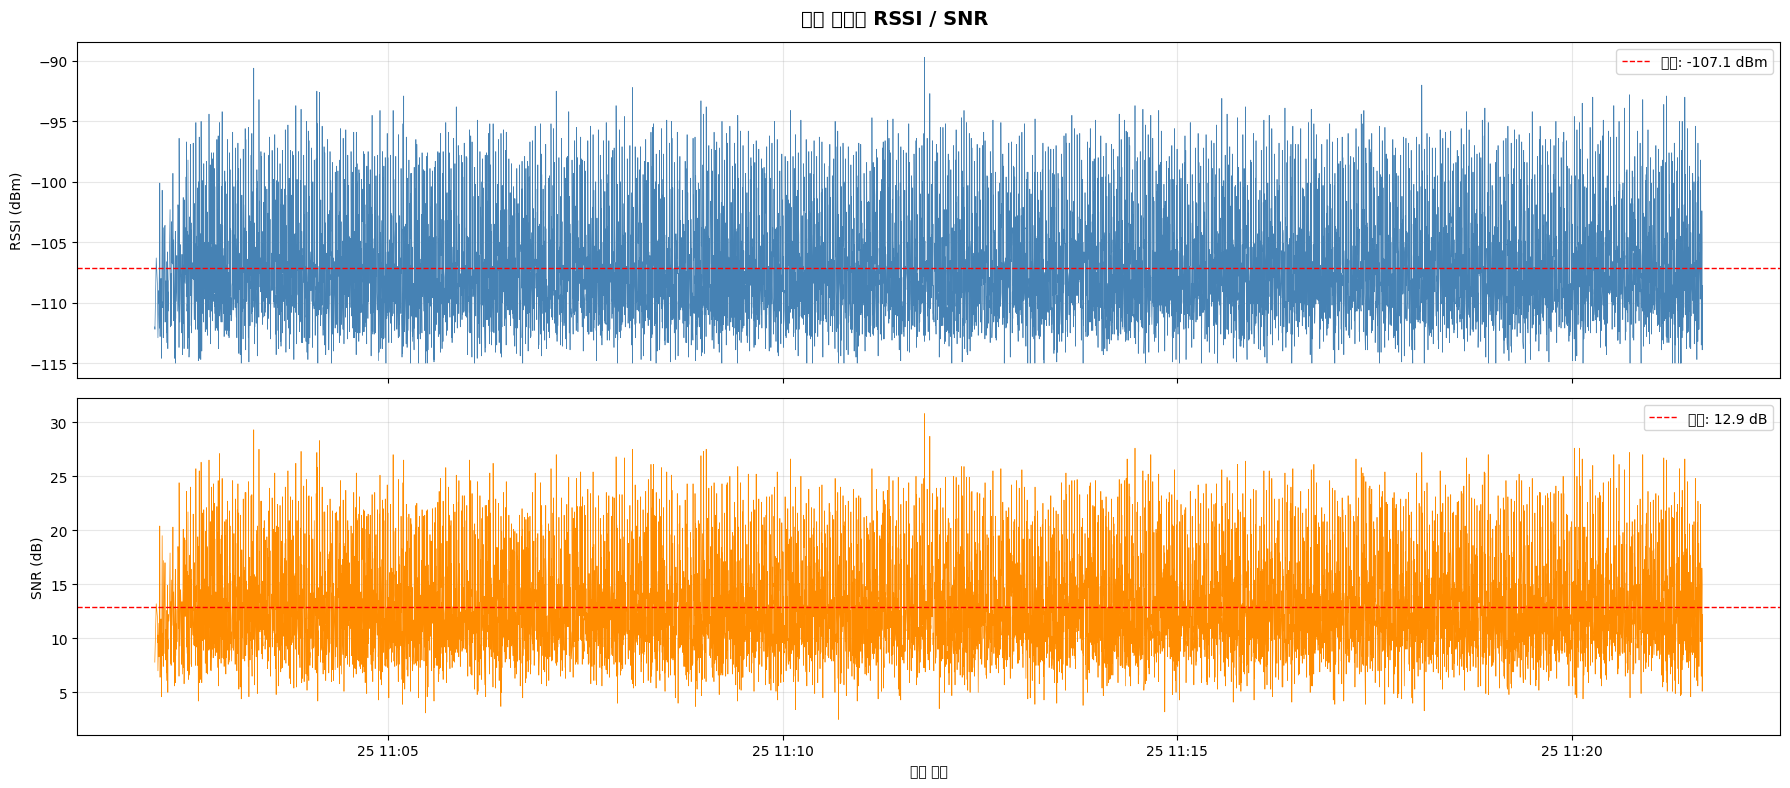

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)
fig.suptitle("수신 시각별 RSSI / SNR", fontsize=14, fontweight="bold")

axes[0].plot(df_sort["date_bucket"], df_sort["rssi"], linewidth=0.5, color="steelblue")
axes[0].axhline(df_sort["rssi"].mean(), color="red", linestyle="--", linewidth=1,
                label=f"평균: {df_sort['rssi'].mean():.1f} dBm")
axes[0].set_ylabel("RSSI (dBm)")
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_sort["date_bucket"], df_sort["snr"], linewidth=0.5, color="darkorange")
axes[1].axhline(df_sort["snr"].mean(), color="red", linestyle="--", linewidth=1,
                label=f"평균: {df_sort['snr'].mean():.1f} dB")
axes[1].set_ylabel("SNR (dB)")
axes[1].set_xlabel("수신 시각")
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\3312788454.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\3312788454.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\3312788454.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\3312788454.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


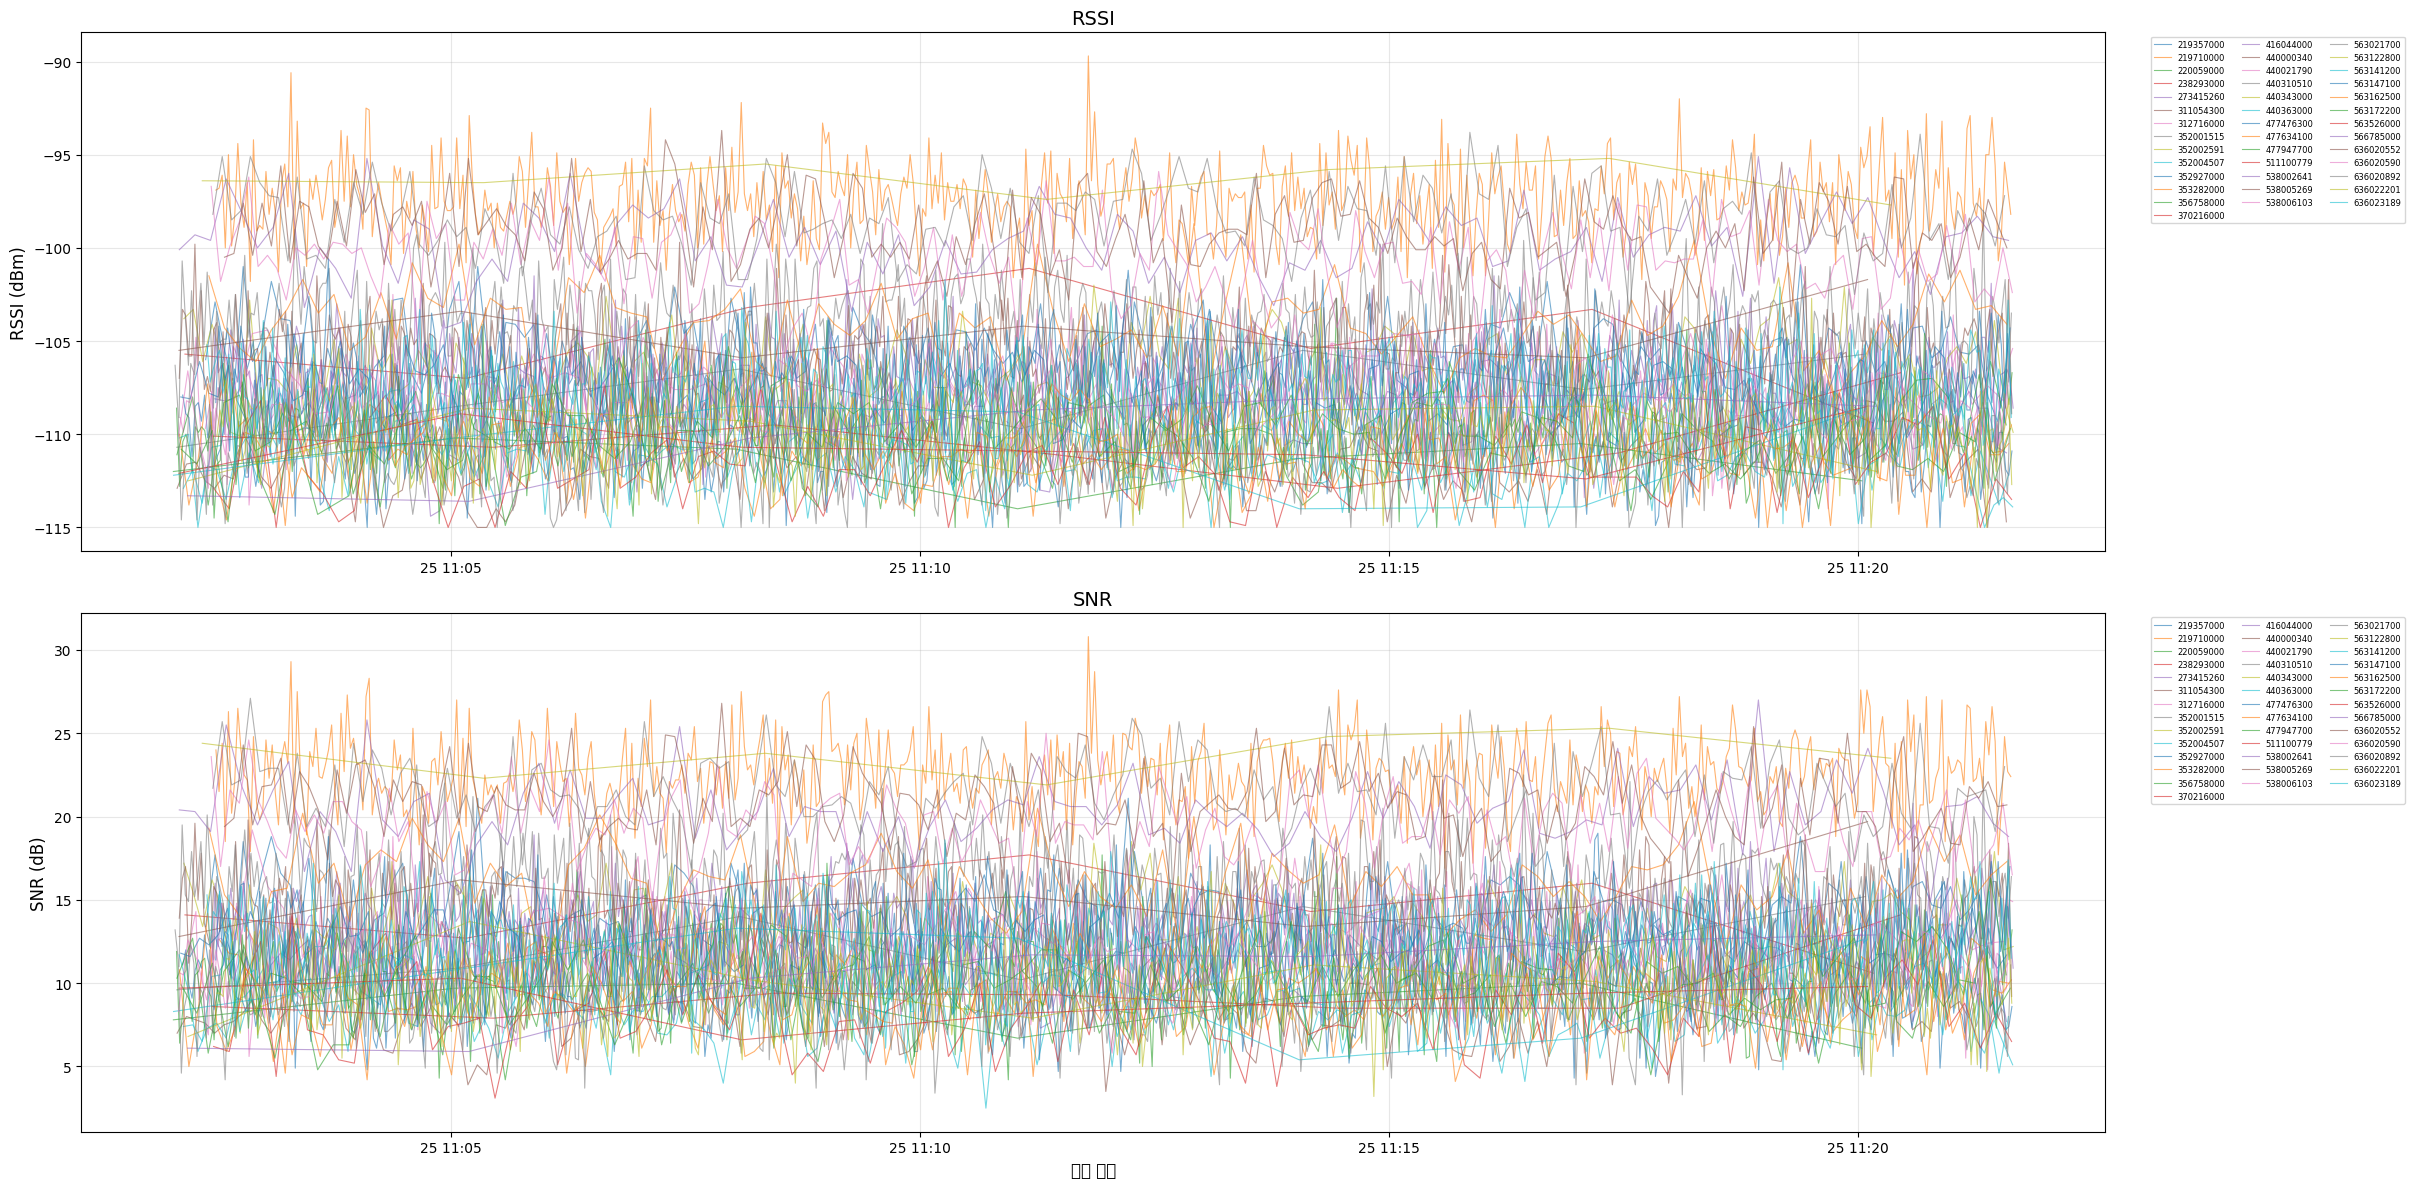

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(24, 12), sharex=False)  # 크기 대폭 확대

for mmsi, sub_df in df_sort.groupby("mmsi"):
    axes[0].plot(sub_df["date_bucket"], sub_df["rssi"], label=mmsi, alpha=0.6, linewidth=0.8)
    axes[1].plot(sub_df["date_bucket"], sub_df["snr"],  label=mmsi, alpha=0.6, linewidth=0.8)

axes[0].set_title("RSSI", fontsize=14)
axes[0].set_ylabel("RSSI (dBm)", fontsize=12)
axes[0].legend(fontsize=6, loc="upper right", ncol=3, bbox_to_anchor=(1.15, 1))
axes[0].grid(True, alpha=0.3)

axes[1].set_title("SNR", fontsize=14)
axes[1].set_ylabel("SNR (dB)", fontsize=12)
axes[1].set_xlabel("수신 시각", fontsize=12)
axes[1].legend(fontsize=6, loc="upper right", ncol=3, bbox_to_anchor=(1.15, 1))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

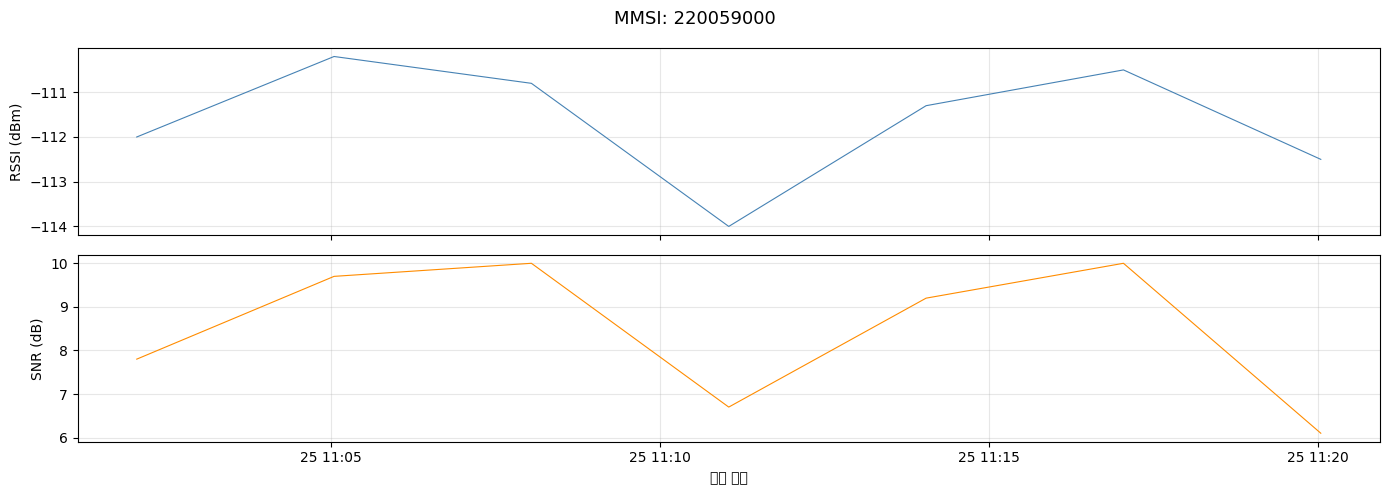

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

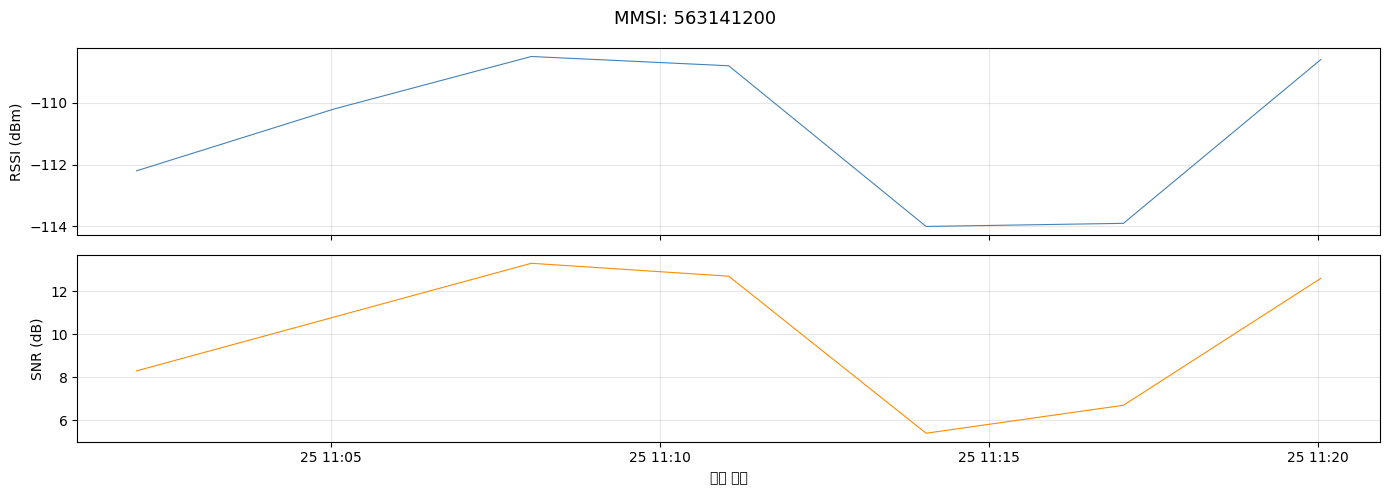

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

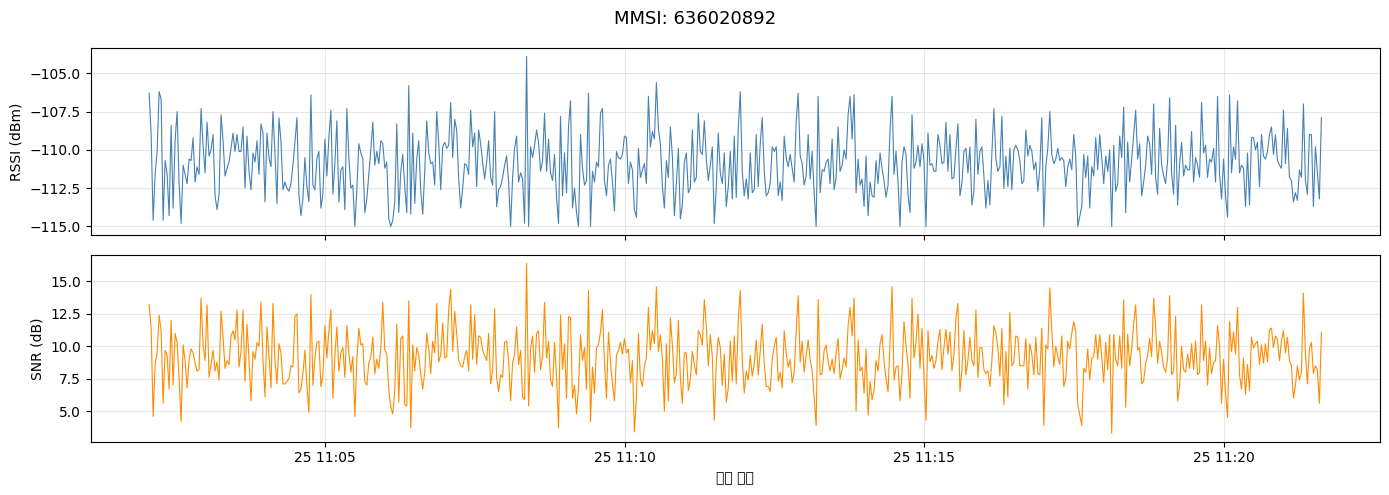

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

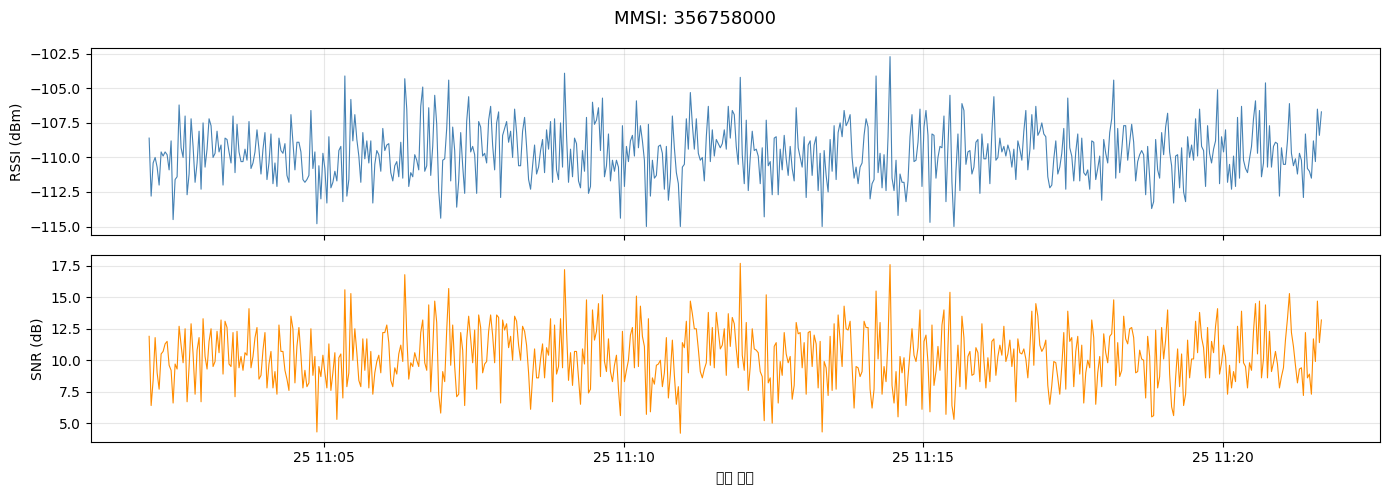

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

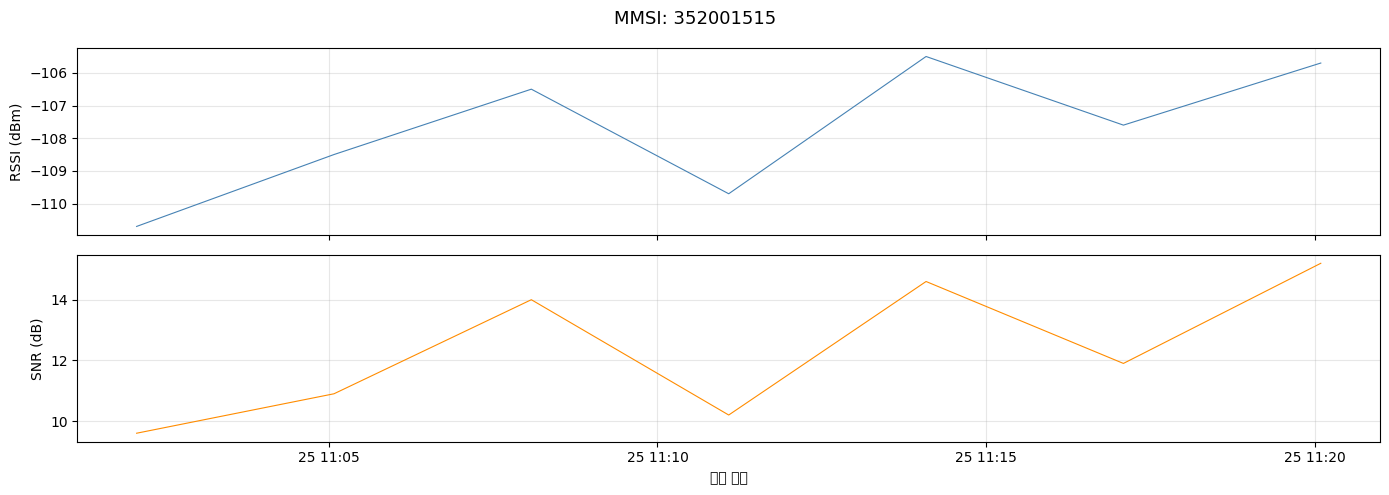

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

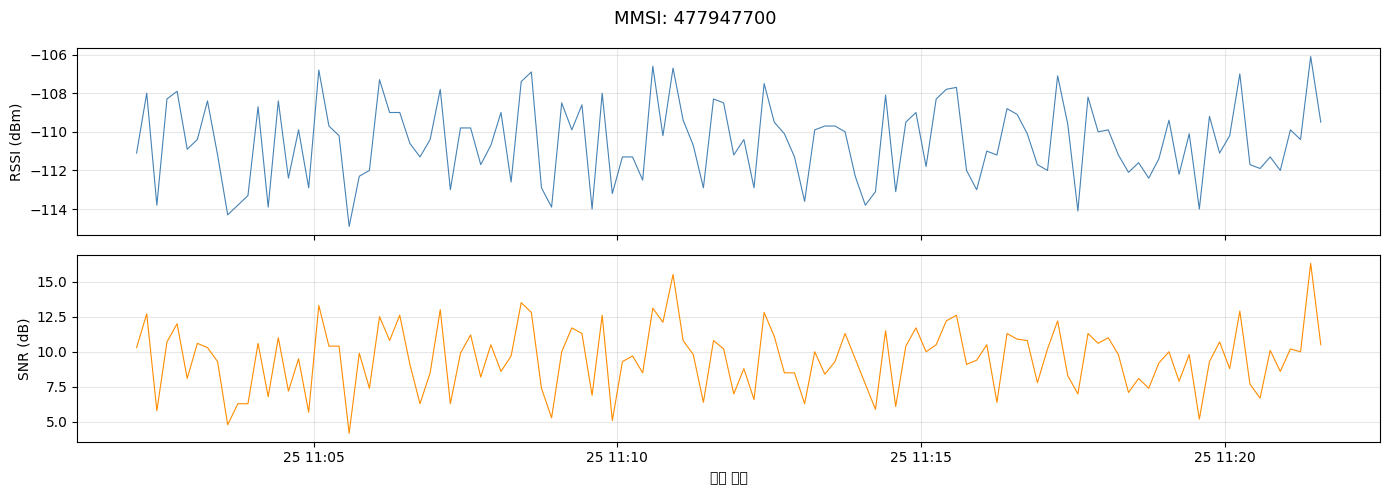

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

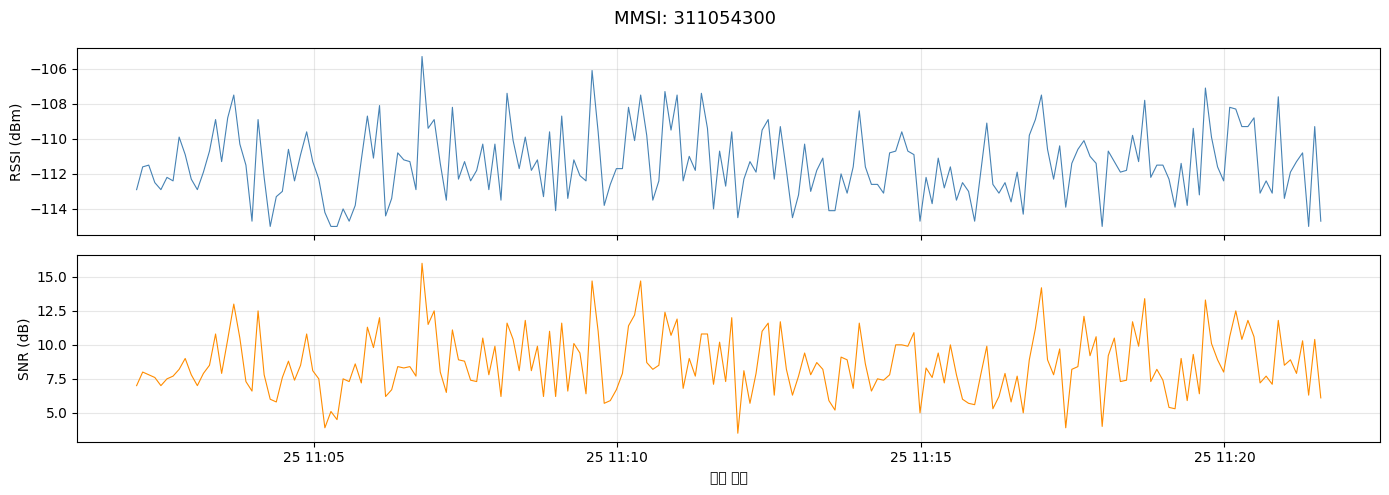

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

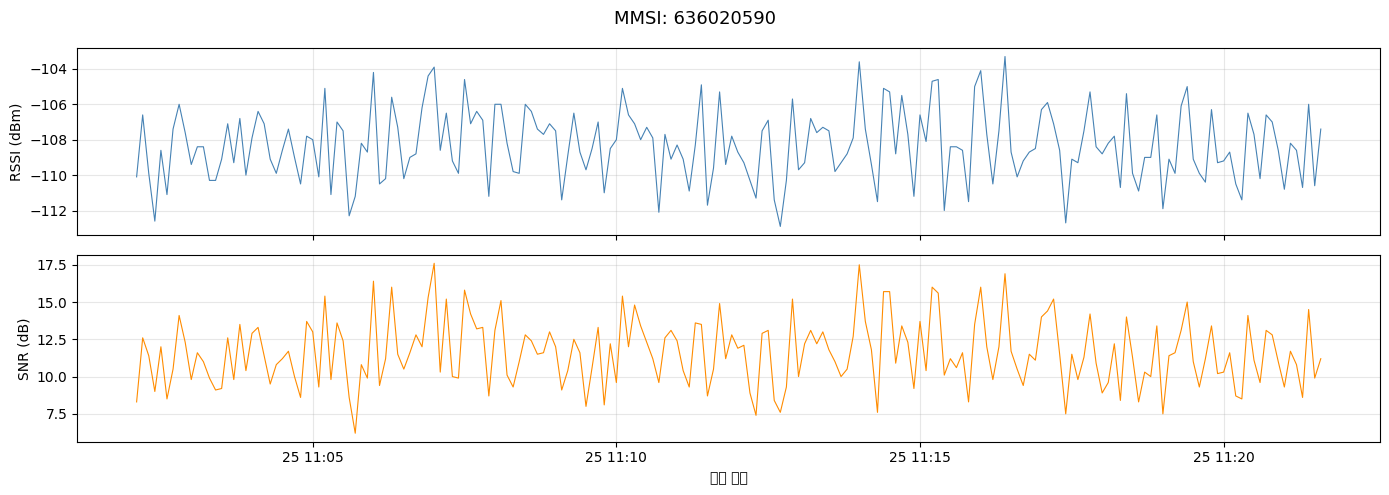

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

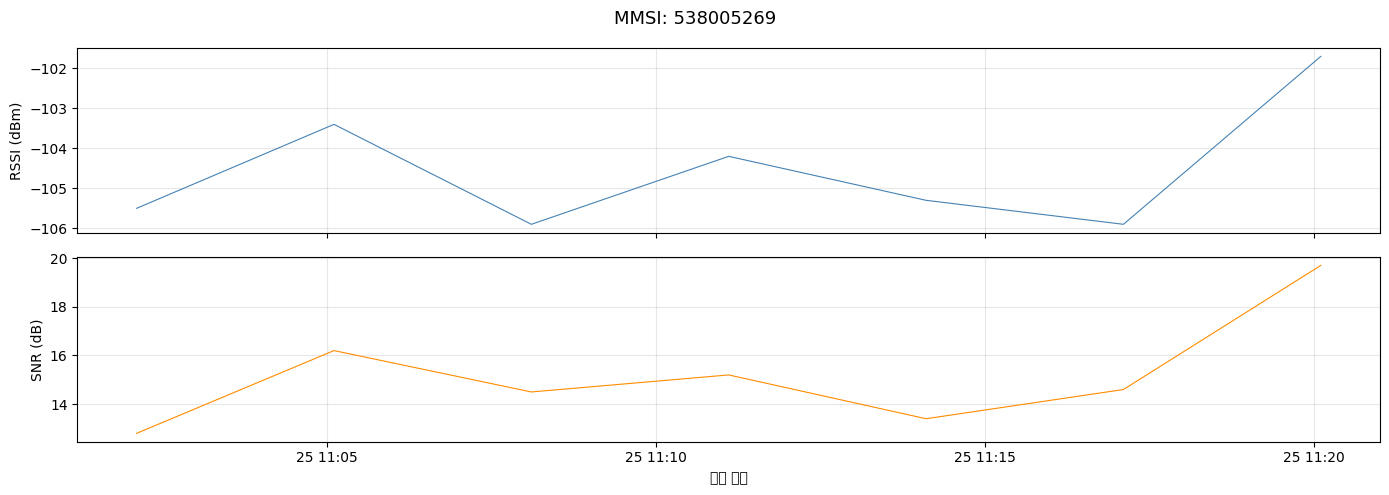

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

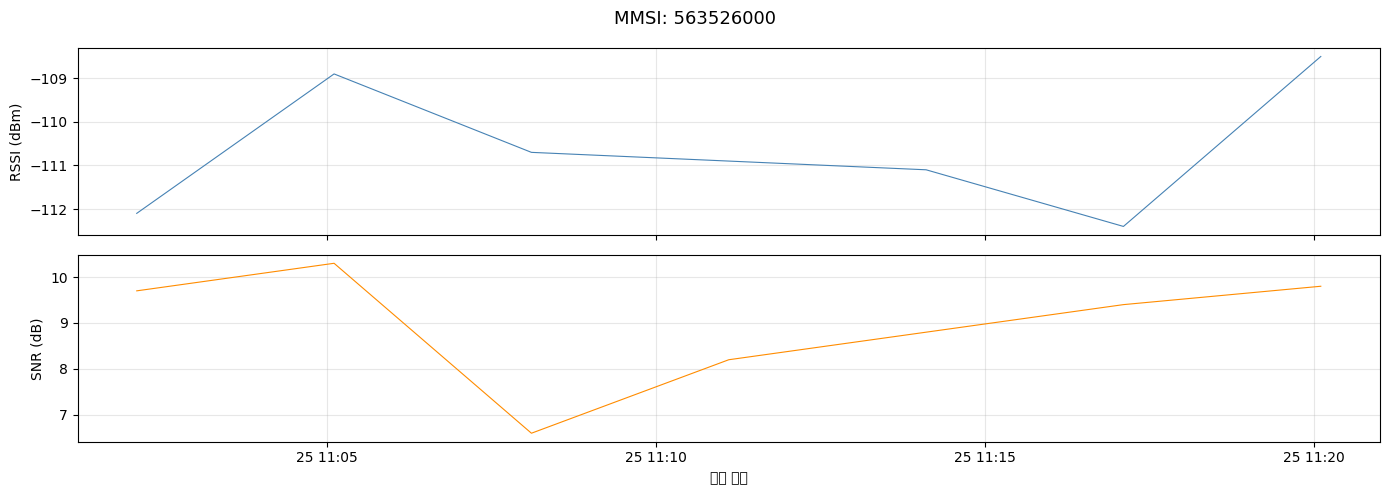

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

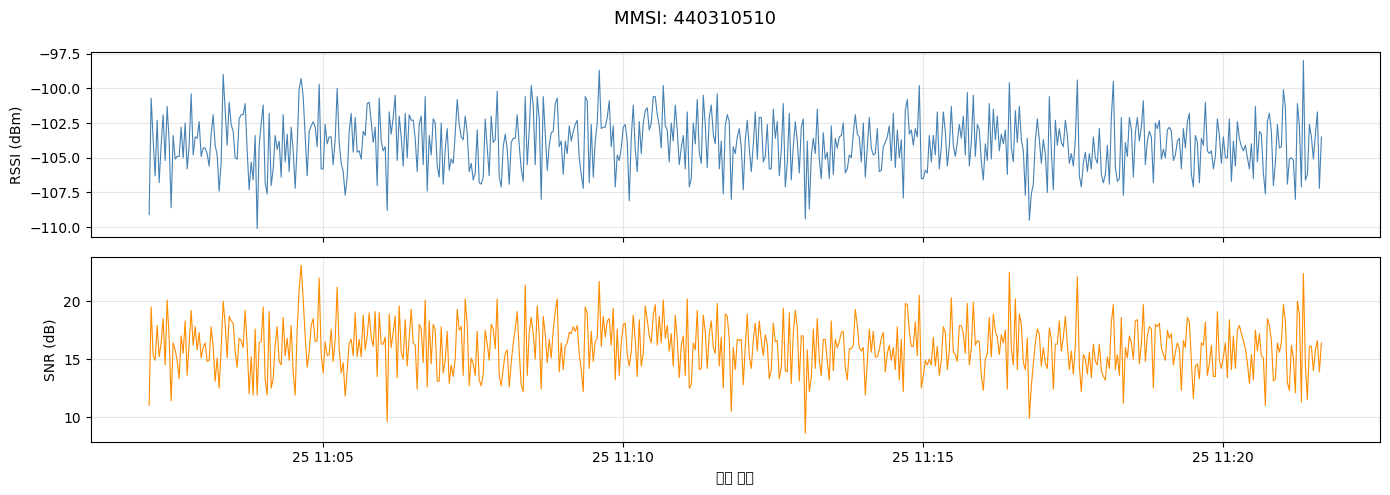

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

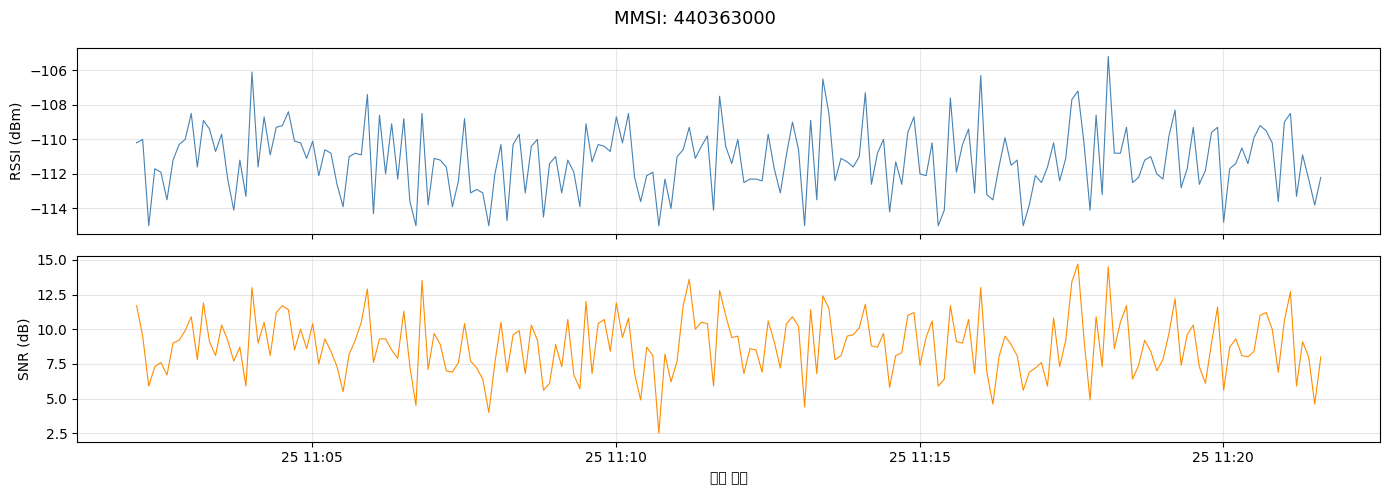

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

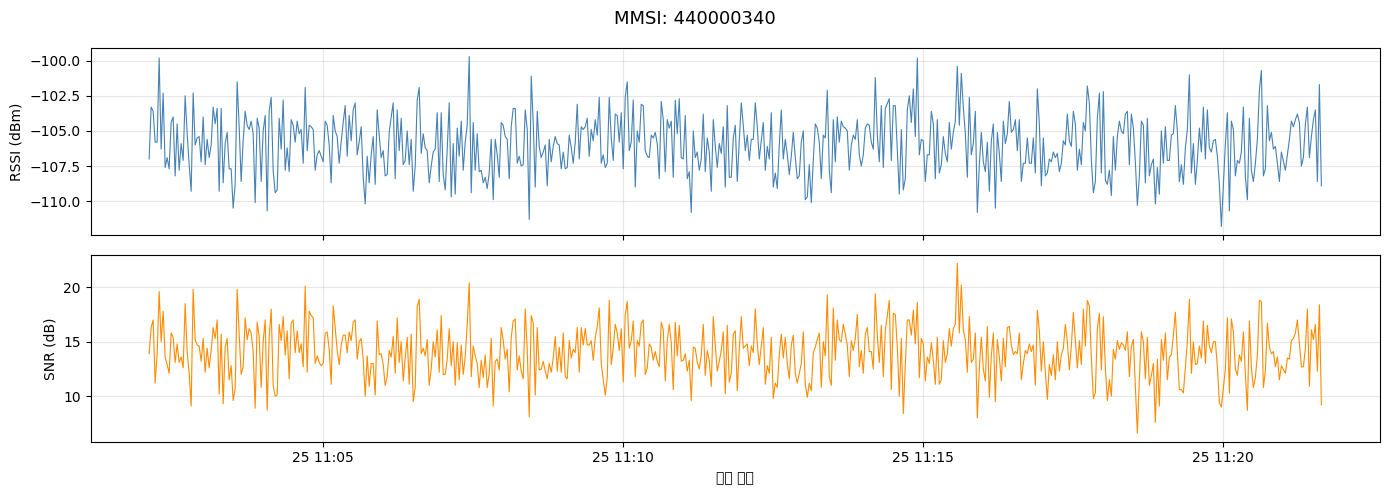

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

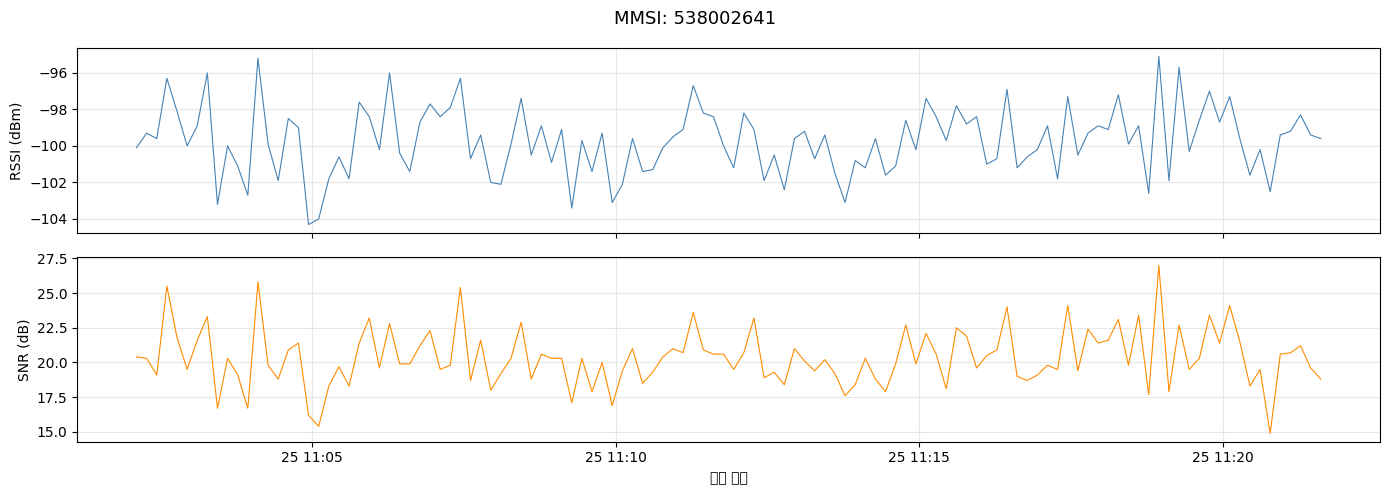

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

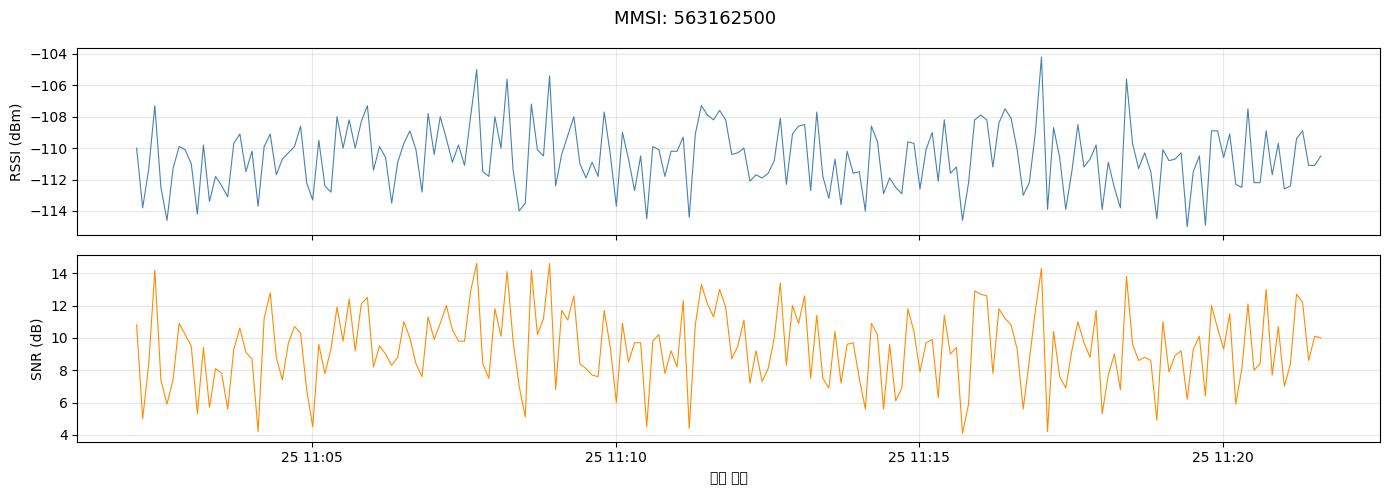

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

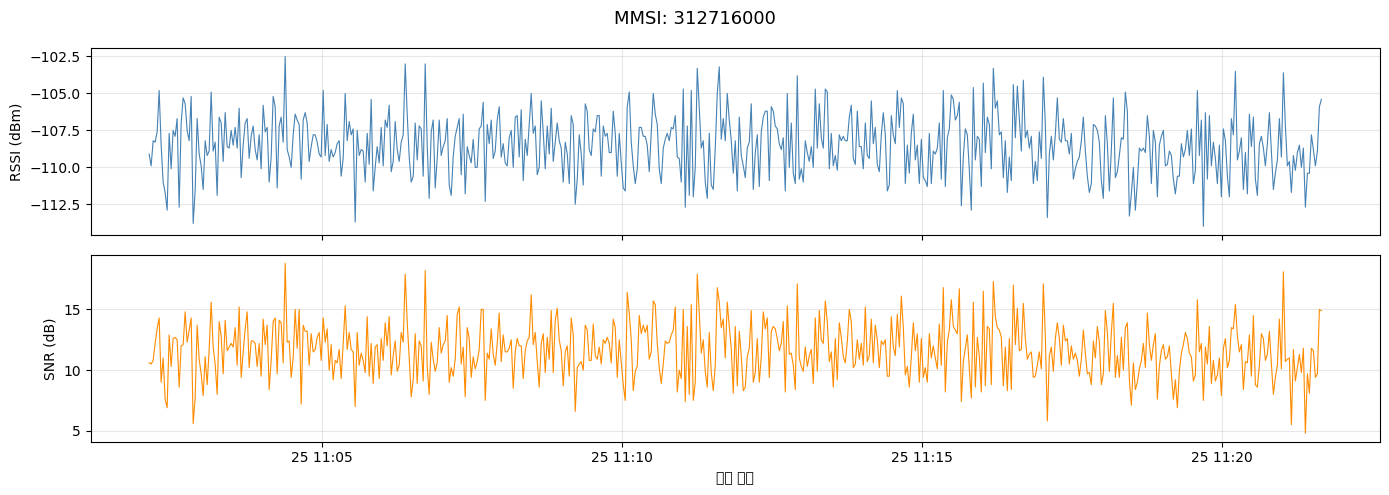

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

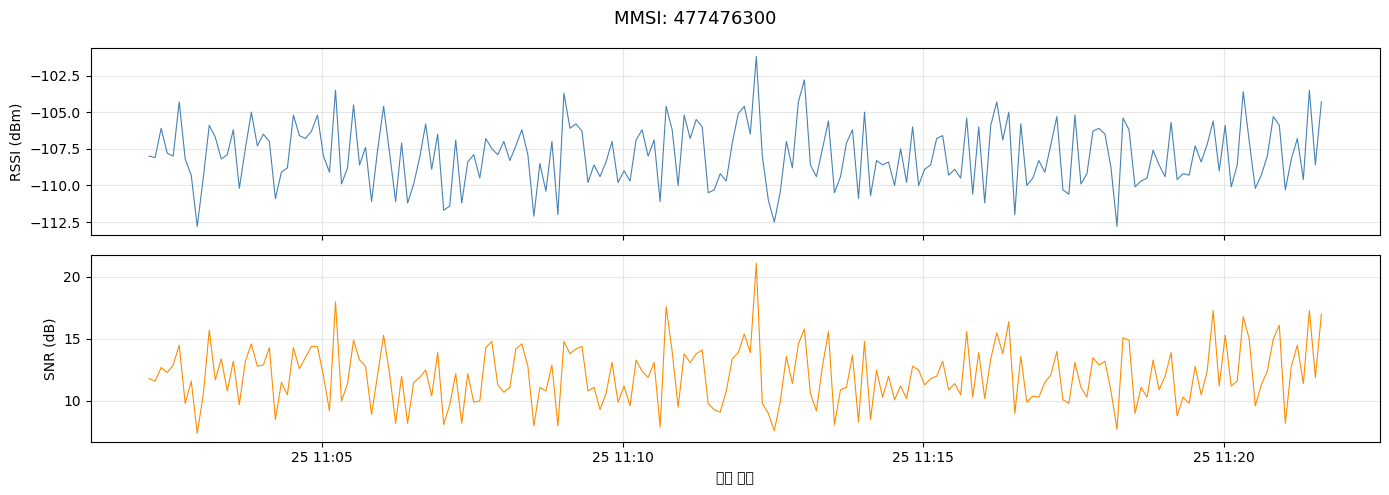

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

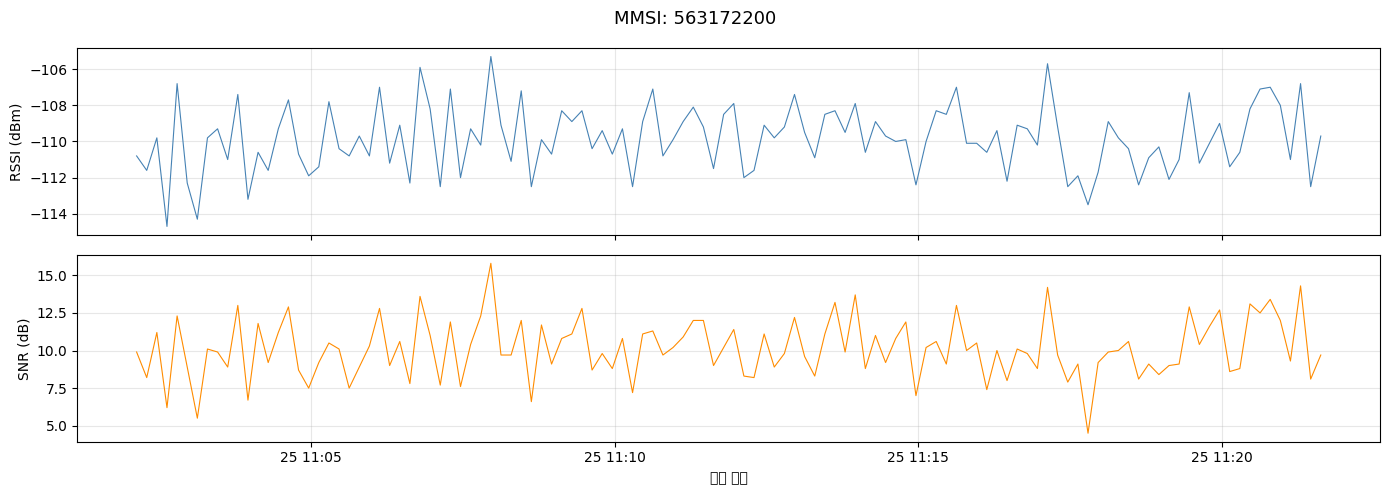

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

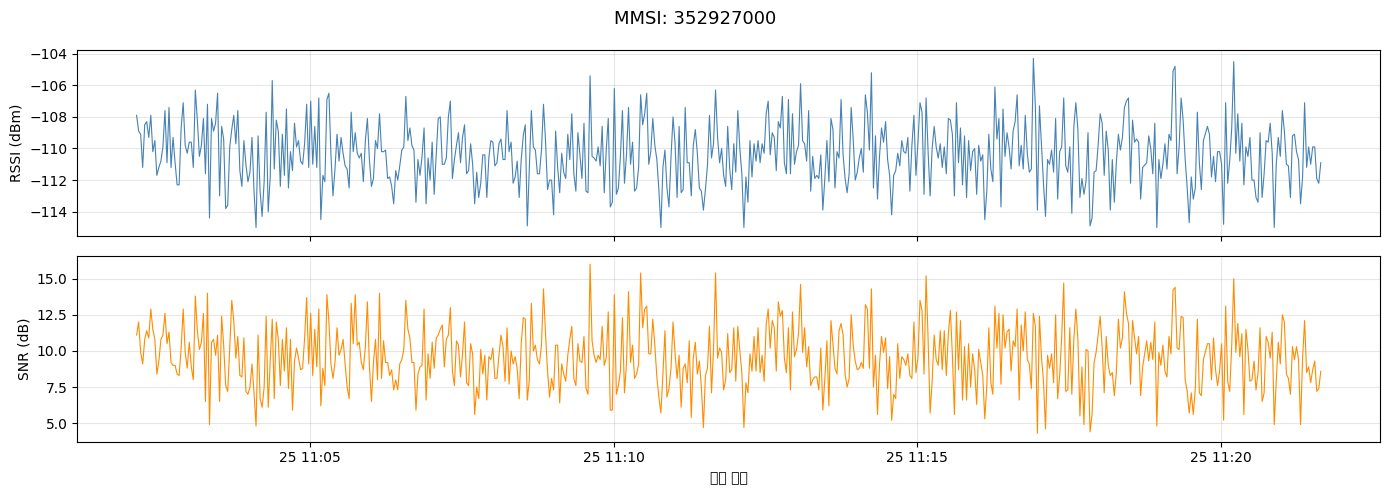

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

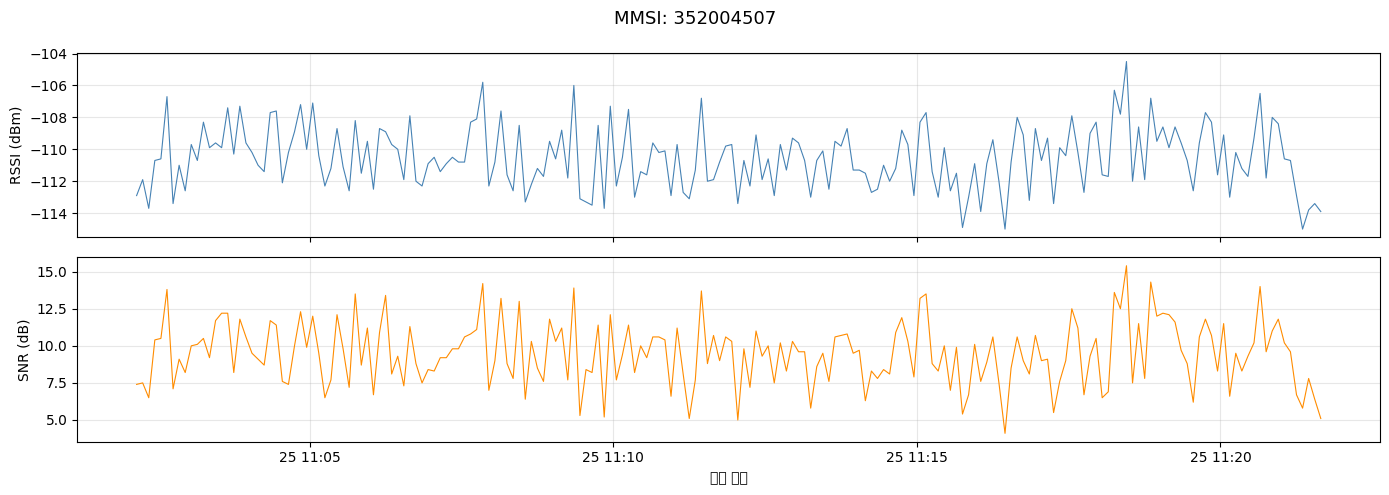

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

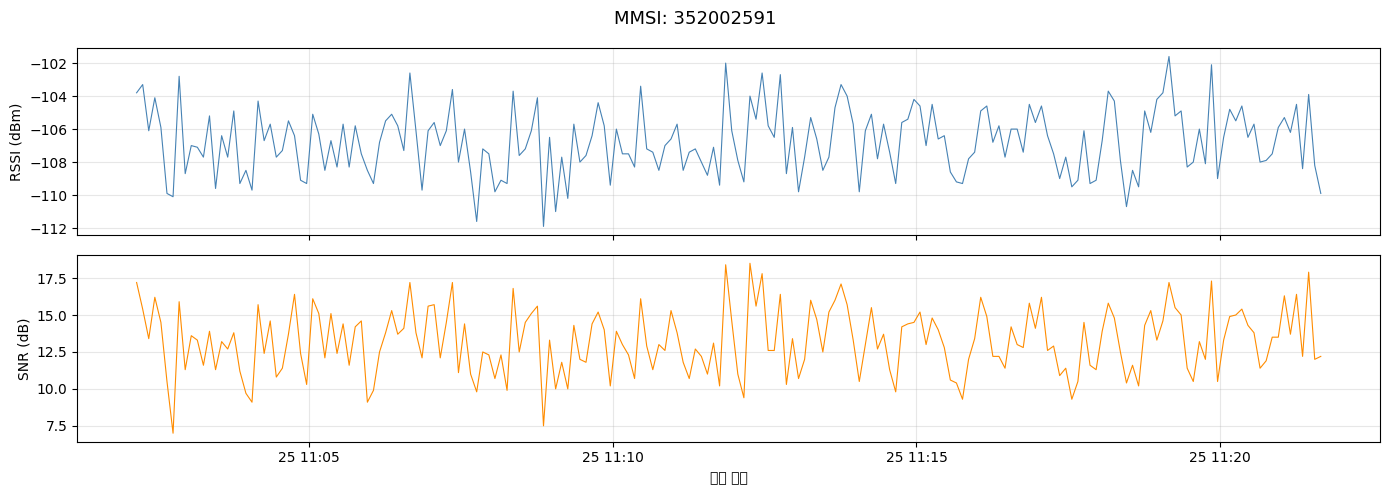

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

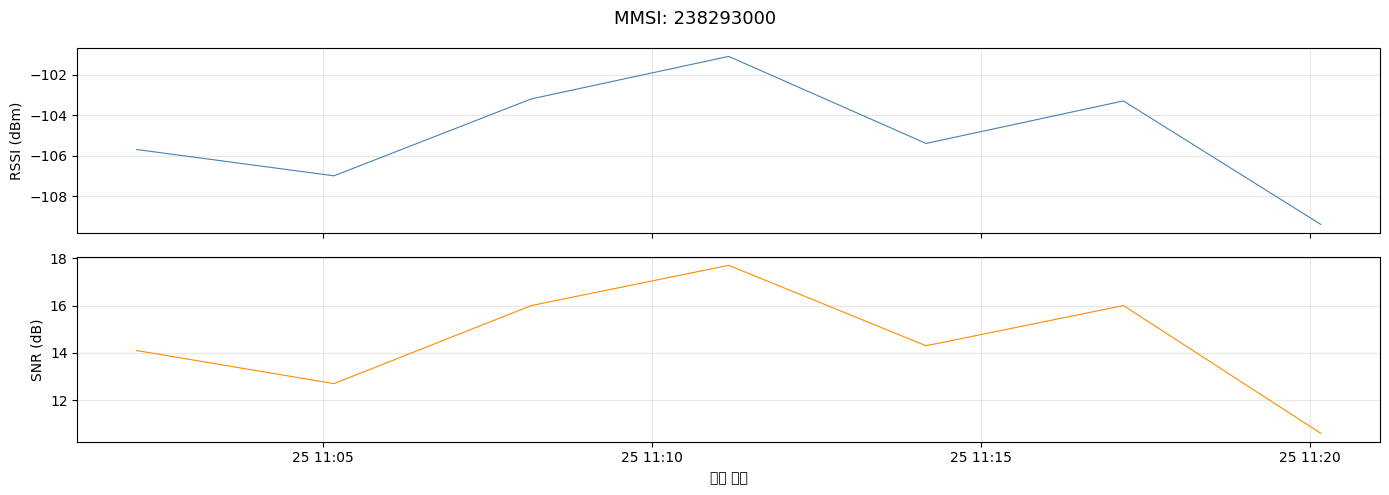

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

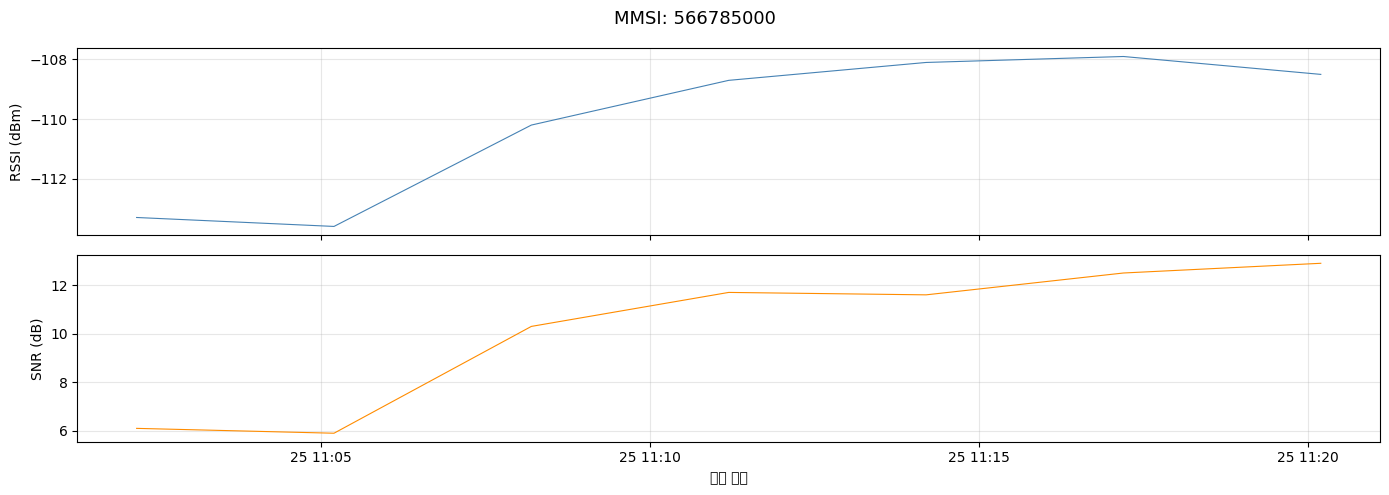

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

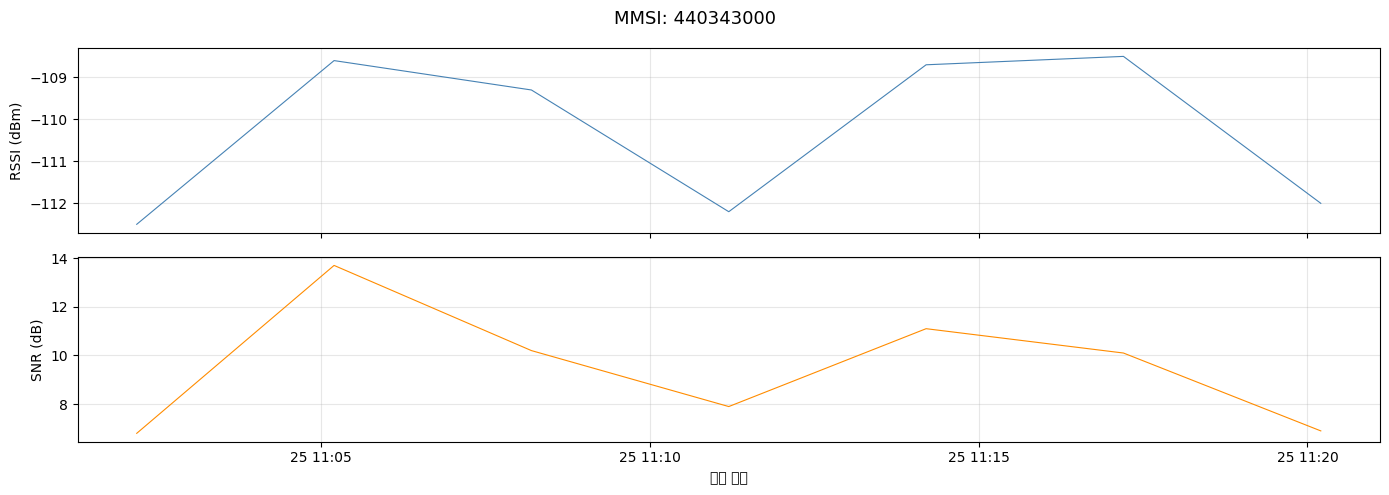

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

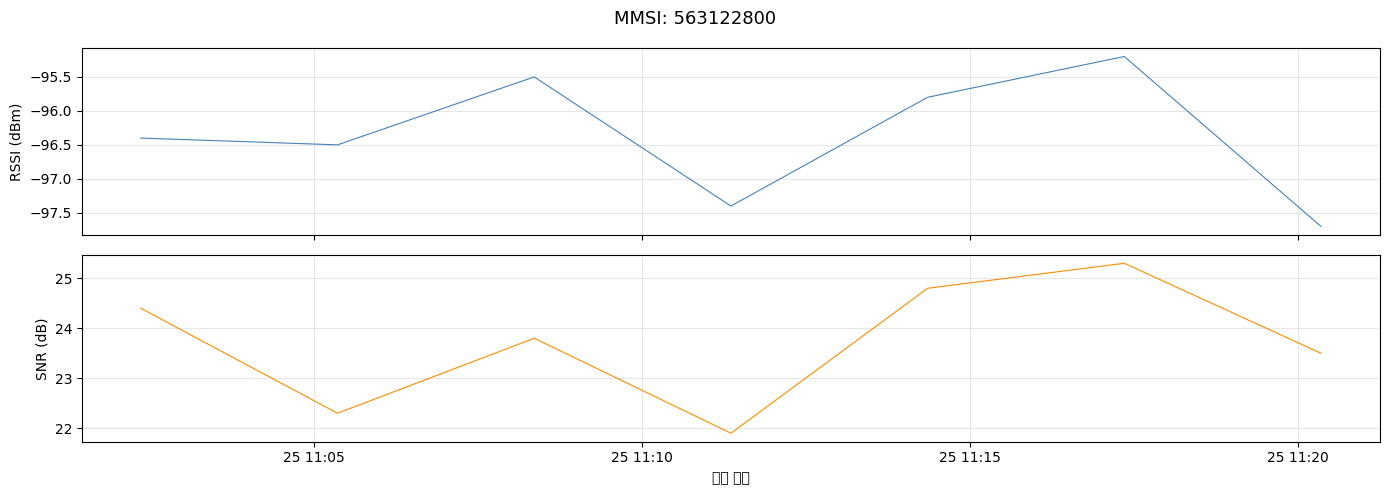

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

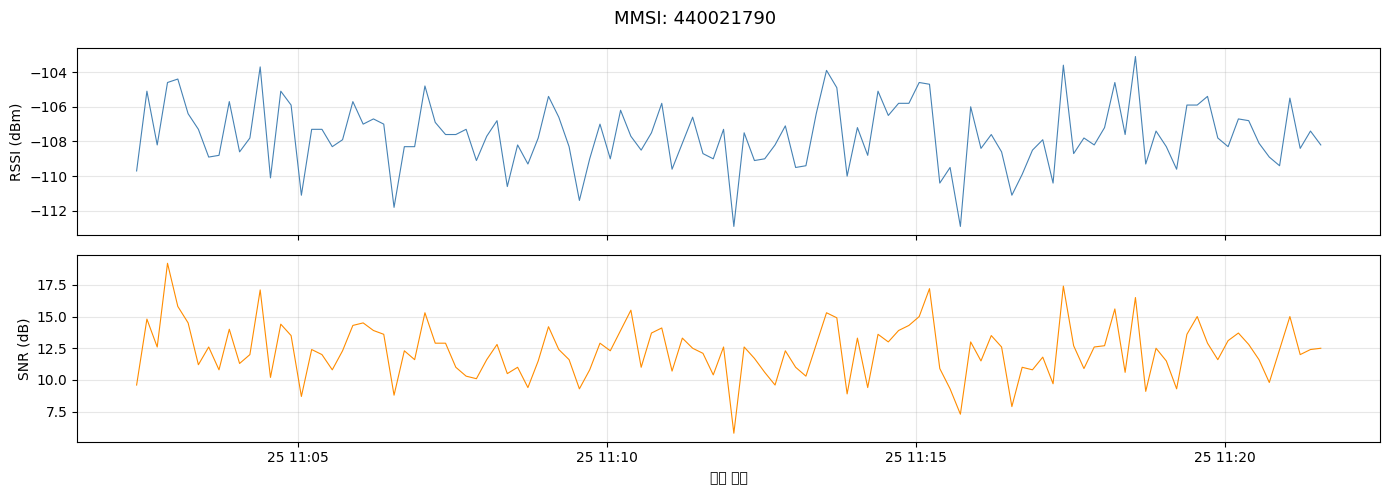

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

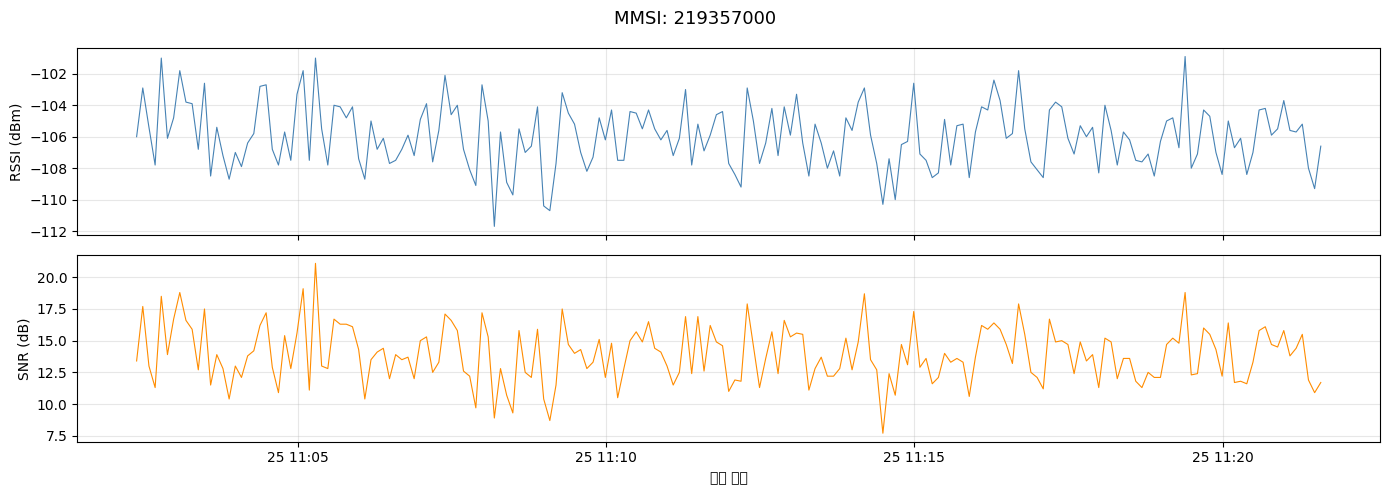

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

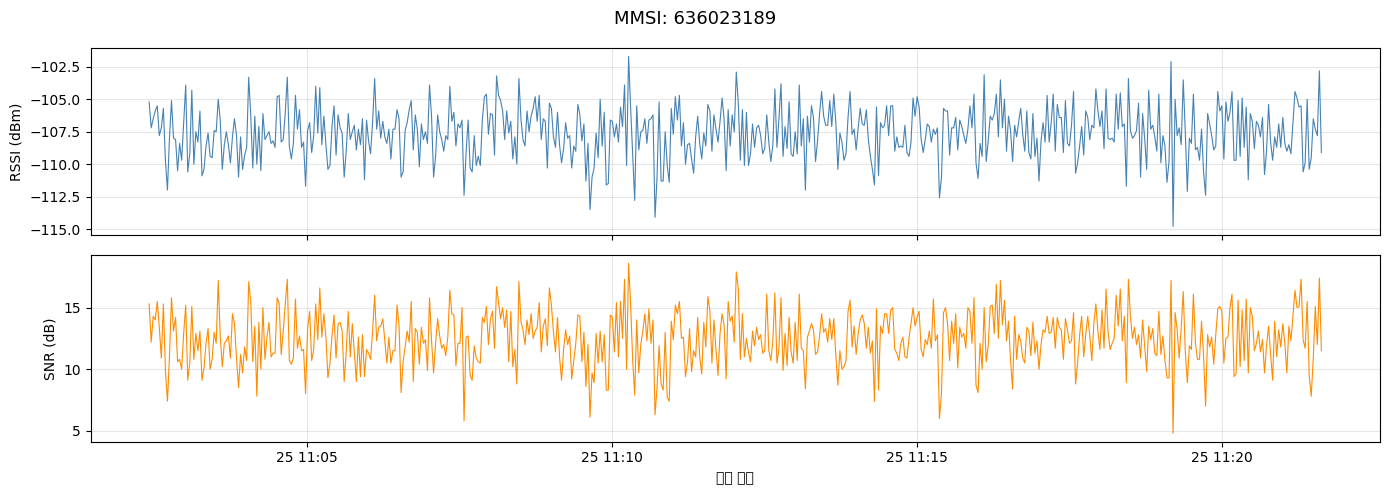

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

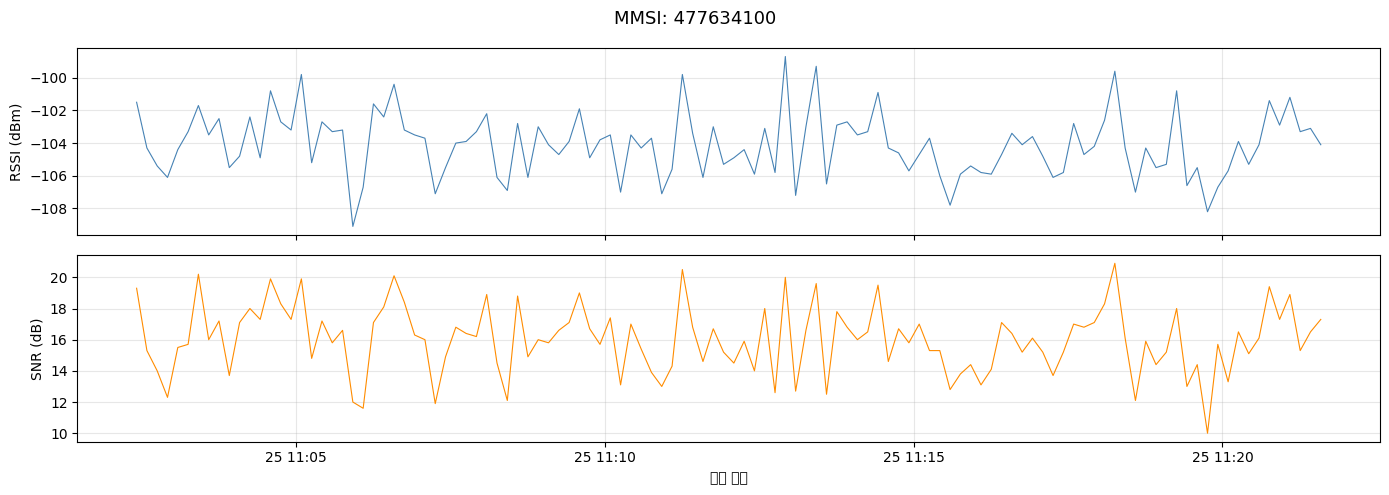

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

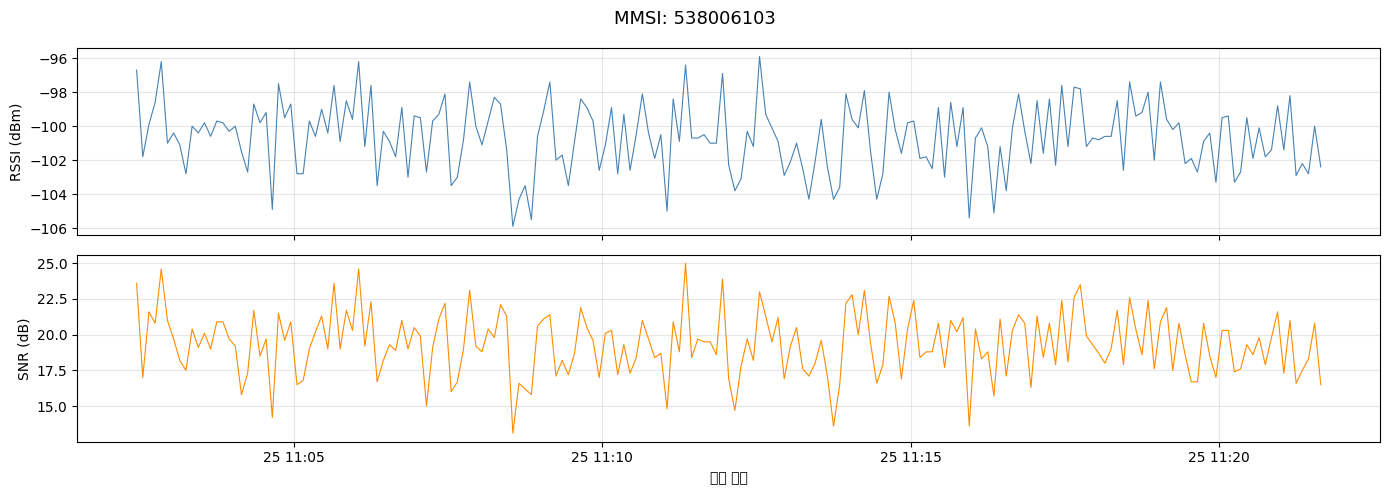

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

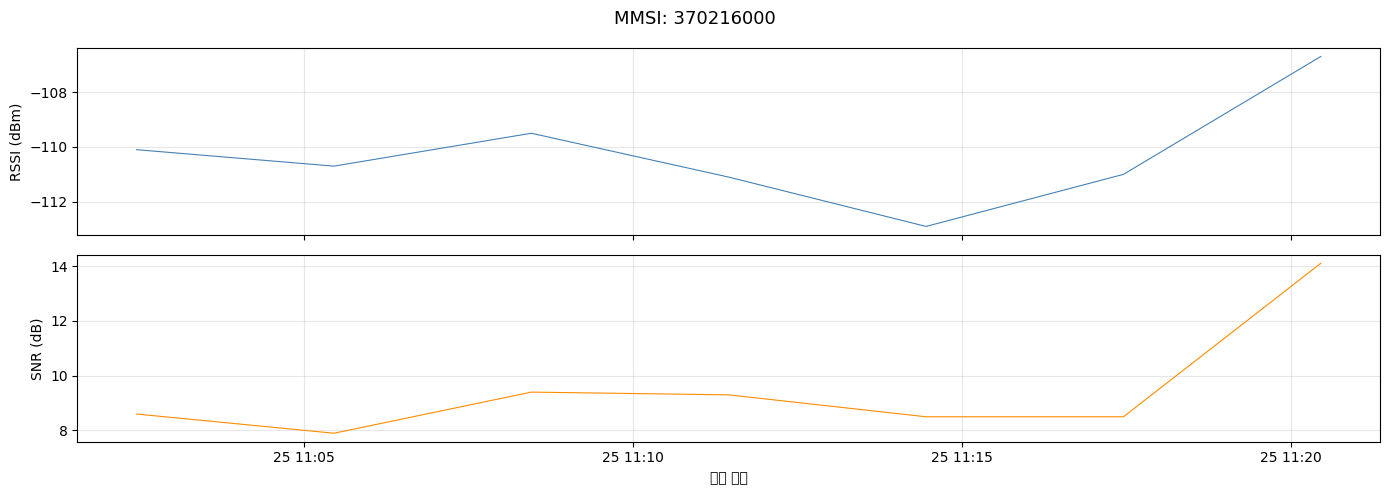

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

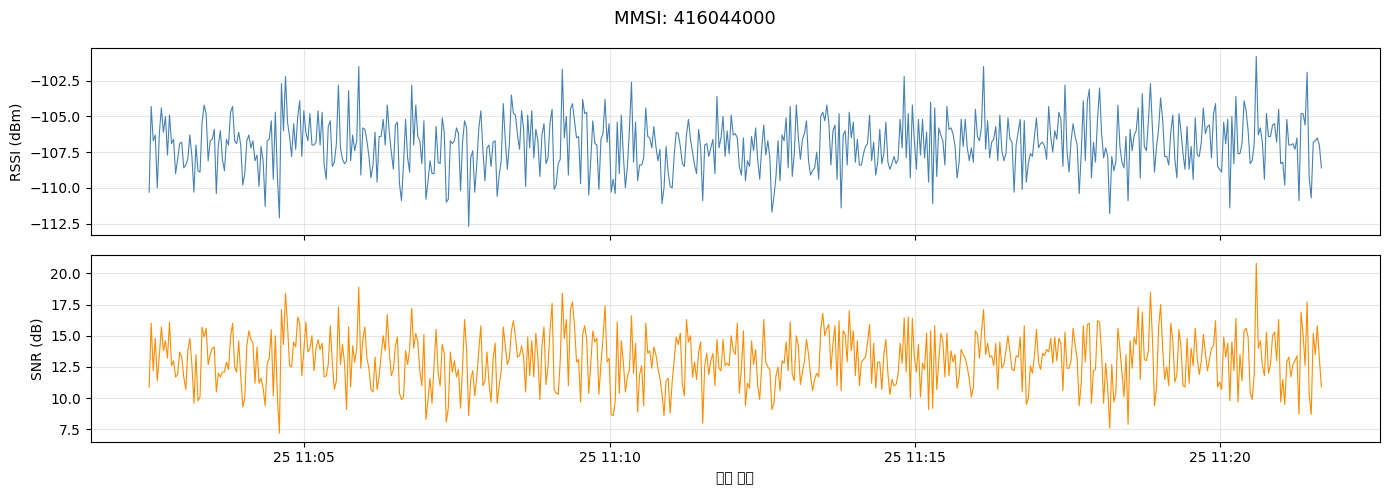

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

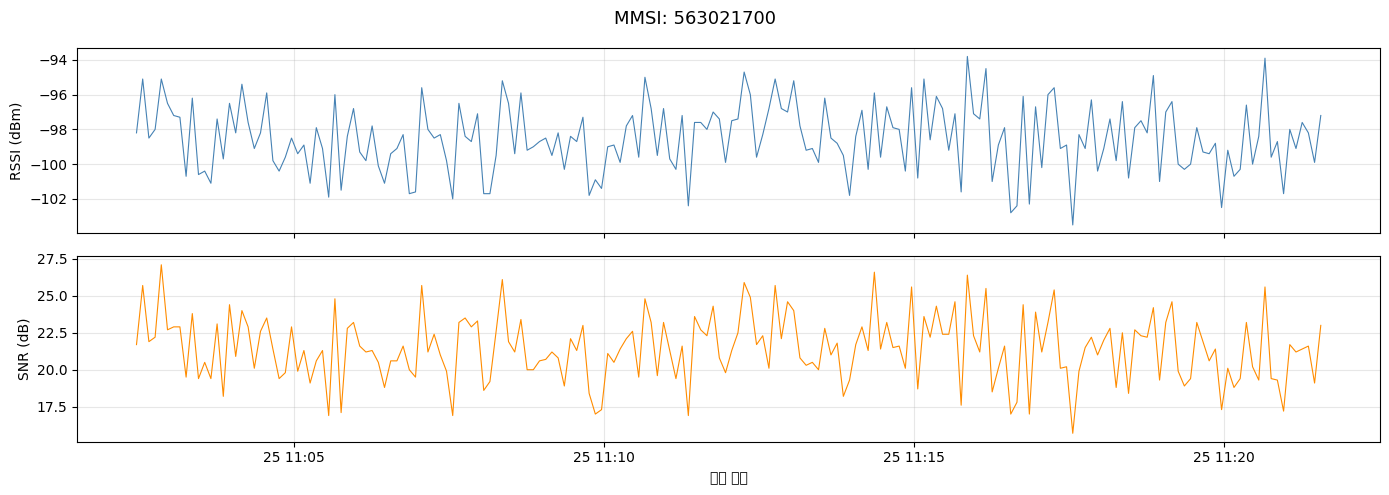

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

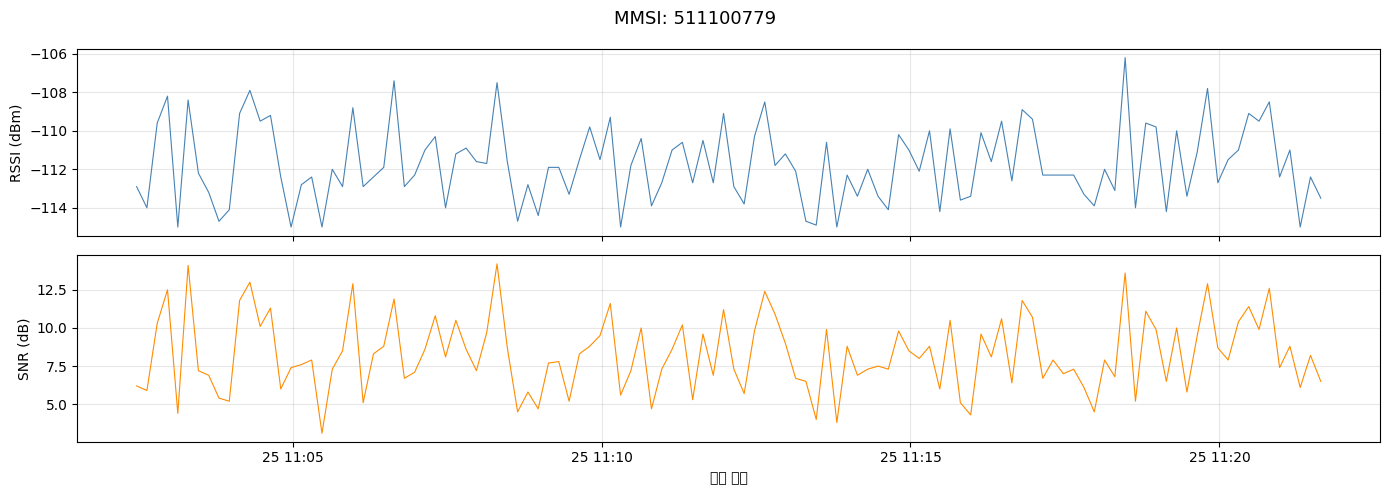

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

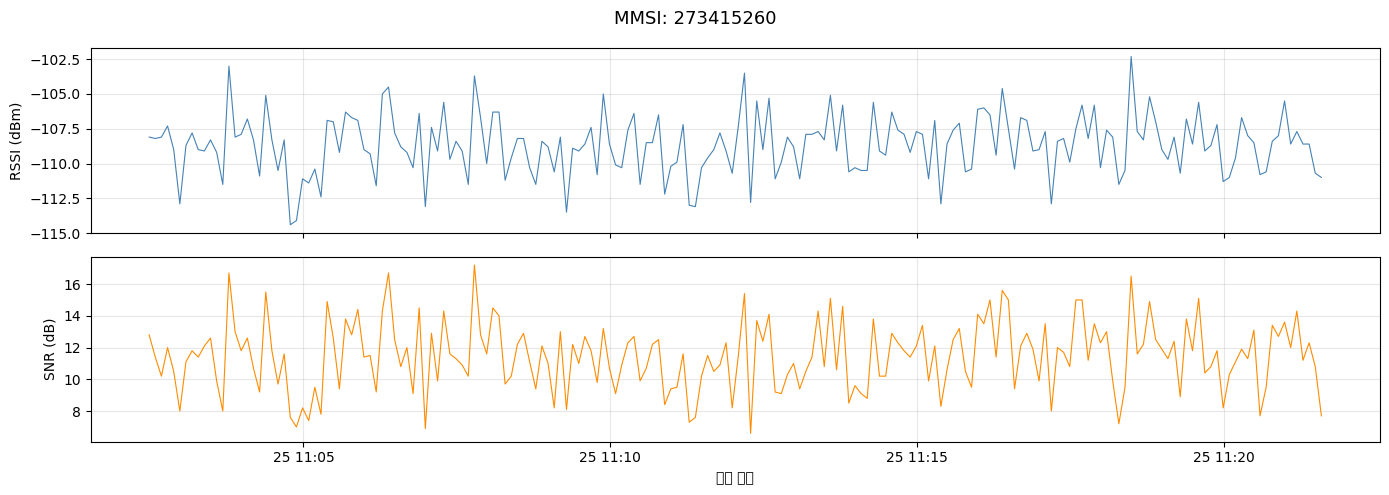

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

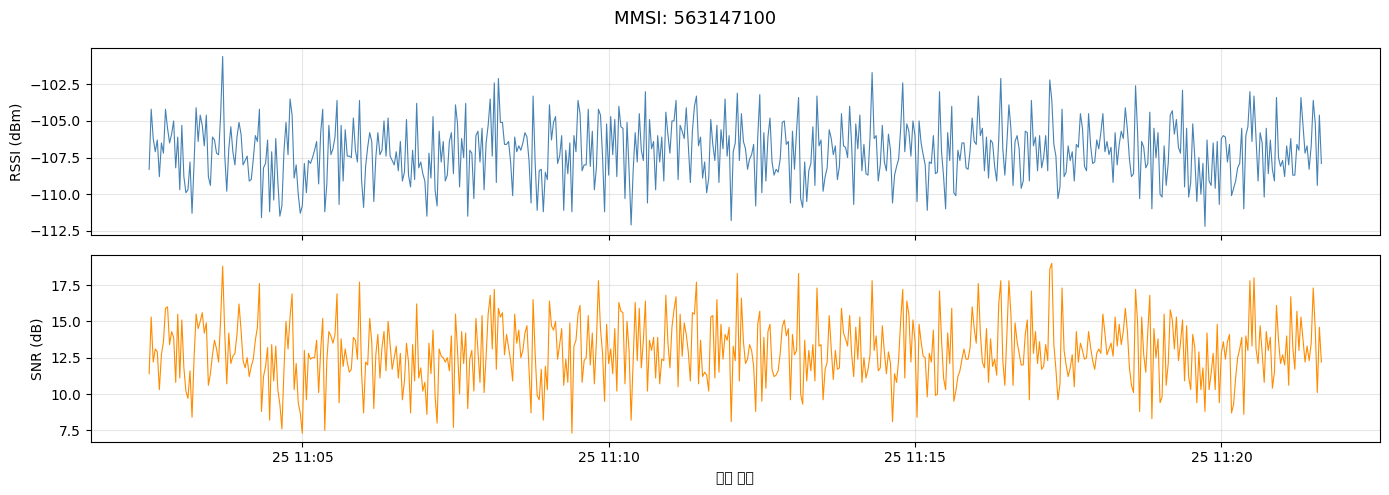

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

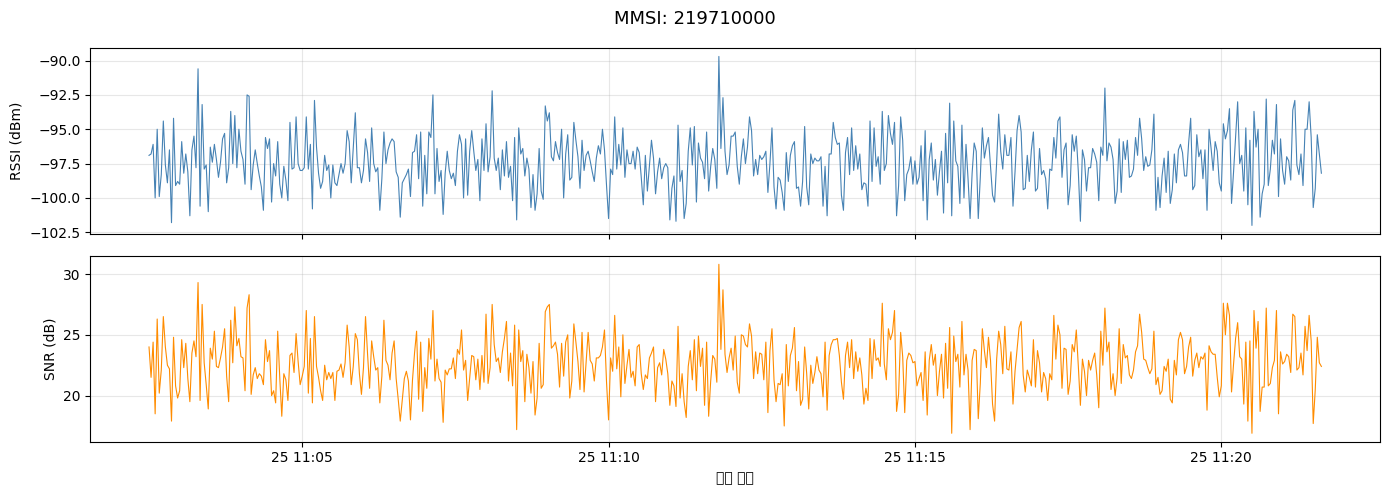

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

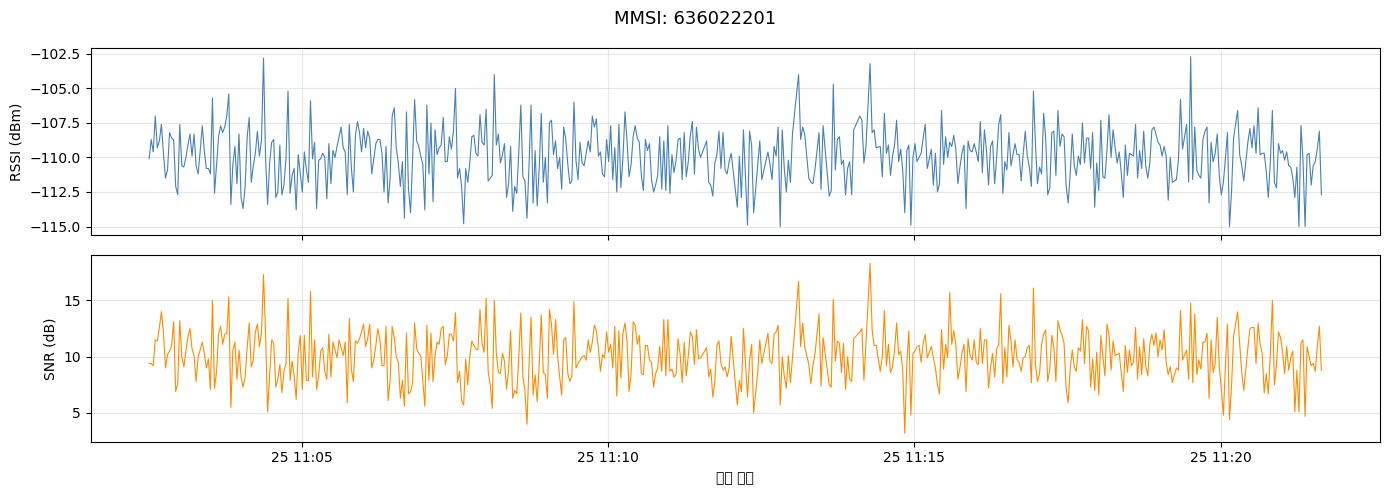

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

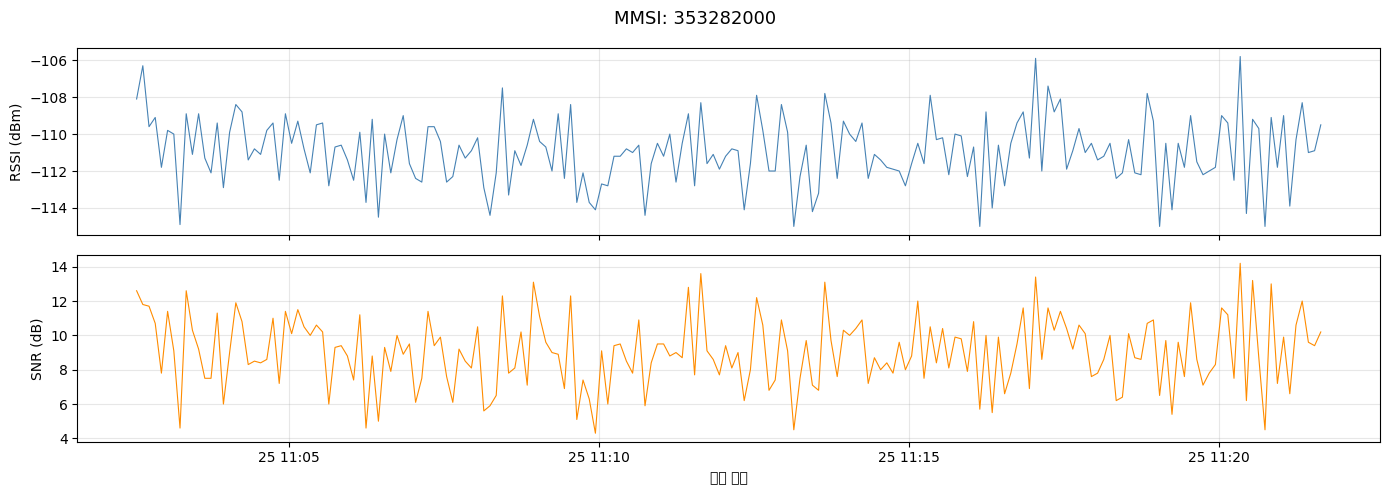

C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dahun\AppData\Local\Temp\ipykernel_39812\1723453702.py:20: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dahun\Desktop\message_generator\spark-analysis\venv\Lib\site

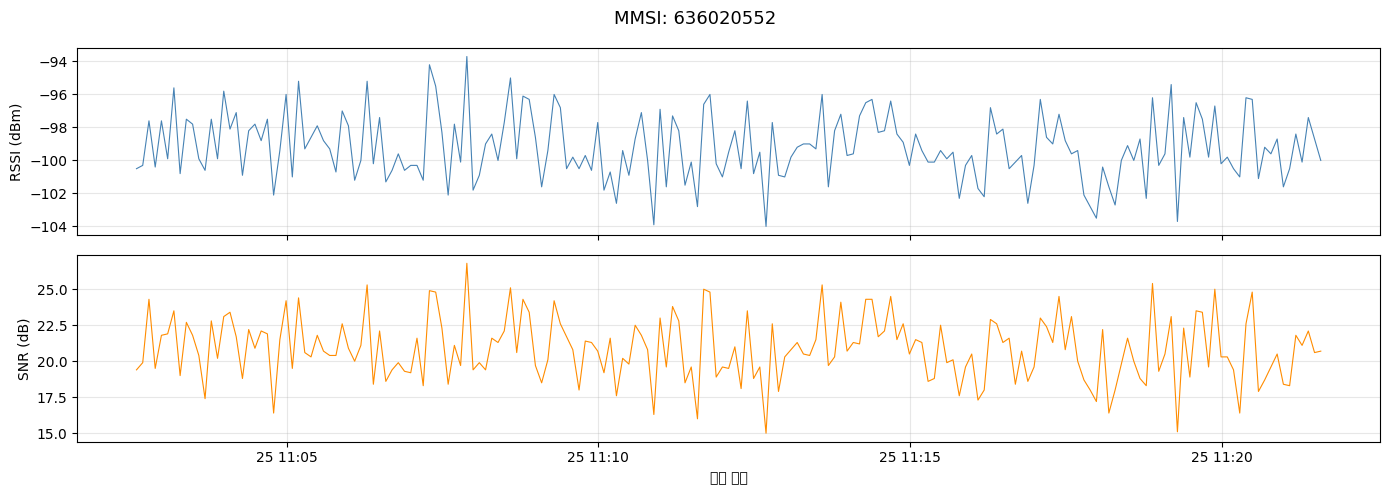

In [36]:
import matplotlib.pyplot as plt

mmsi_list = df_sort["mmsi"].unique()

for mmsi in mmsi_list:
    sub = df_sort[df_sort["mmsi"] == mmsi].sort_values("date_bucket")

    fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
    fig.suptitle(f"MMSI: {mmsi}", fontsize=13)

    axes[0].plot(sub["date_bucket"], sub["rssi"], linewidth=0.8, color="steelblue")
    axes[0].set_ylabel("RSSI (dBm)")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(sub["date_bucket"], sub["snr"], linewidth=0.8, color="darkorange")
    axes[1].set_ylabel("SNR (dB)")
    axes[1].set_xlabel("수신 시각")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()